# RoboCasa — Project B : Atomic Door-Opening Task with PandaOmron

**Telecom Paris — Reinforcement Learning Project, Spring 2026**

---

## Abstract

This report documents Project B of the RoboCasa reinforcement learning assignment, in which we trained a
PandaOmron robot to perform the **OpenCabinet** atomic task — opening a kitchen cabinet door from scratch
using model-free RL. We deliberately chose **not** to use an easy configuration or curriculum that would
simplify the task artificially.

We split the work into two parallel algorithm tracks in order to maximise the chance of achieving a
success rate above 0% with at least one approach:

- **SAC track** — 4 successive variants (v1 → v3 Curriculum) across ~2.3 million steps, plus an ongoing
  SAC+HER experiment. Focus: diagnosing entropy collapse, stabilising the critic, and addressing the
  cold start problem.
- **PPO track** — iterative reward chain (~1.16 million steps) and a 1M-step clean fresh-start run.
  Focus: reward shaping, reward-hacking detection, and sub-skill characterisation.

Combined, we accumulated approximately **~5 million environment steps** across both tracks. Neither
algorithm achieved `success_rate > 0%`, but the two tracks produced complementary diagnostic results:
SAC failures yielded a precise quantitative account of the entropy collapse mechanism and the cold start
problem; PPO failures revealed two distinct reward-hacking behaviours and confirmed measurable partial
sub-skill learning.

**Key findings:**
- SAC's `ent_coef` auto-tuning fails structurally on this task: `log_prob ≈ −20` is always below
  `target_entropy` (−12 or −4), driving α → 0 before any learning — confirmed across v1 (500k) and
  v2 (900k); fixed in v3 with `ent_coef=0.1` fixed.
- Even with stable entropy (v3/v3_curriculum), SAC encountered a cold start problem: the replay
  buffer accumulated ~2.3M transitions with `success_frac = 0`, giving the critic no positive signal
  to learn from. HER (Hindsight Experience Replay) is the current response.
- PPO learned measurable sub-skills (approach ~5–8 cm, grasp closure ~78%) but was blocked by reward
  hacking and ultimately by the exploration difficulty of sustained contact pulling.
- Both tracks converge on the same conclusion: the task likely requires demonstration-based methods
  to bootstrap the fine-grained contact interaction.


---
### How to read this report

Rather than documenting a single successful training run, this report is an iterative investigation
into **why model-free RL struggles on contact-rich RoboCasa manipulation** — and what can be done about it.

We split the work into two parallel algorithm tracks: **SAC** (off-policy, entropy-regularised) and
**PPO** (on-policy, actor-critic). The goal was to have at least one track achieve `success_rate > 0%`.
Neither did, but the two tracks produced complementary diagnostic results that together characterise
the full difficulty of the task.

The **PPO track** unfolded in five identifiable phases, each revealing a new bottleneck:

1. **Compute speed** — single-worker training was too slow for meaningful experiments; solved with SubprocVecEnv.
2. **Reward correctness** — reward was silently computed from the wrong MuJoCo bodies; required low-level debugging.
3. **Metric reliability** — `eval_return` masked reward hacking; required adding 10+ diagnostic metrics.
4. **Reward hacking** — two independent incidents (hover abuse, grasp-and-flee) required iterative corrections.
5. **Contact dynamics** — after all the above, the remaining bottleneck is a fundamental exploration problem.

The **SAC track** followed a parallel diagnostic chain:

1. **Entropy collapse (v1/v2)** — auto-tuning of `ent_coef` drives α → 0 before learning; confirmed structural.
2. **Entropy stabilised (v3)** — fixed `ent_coef=0.1` solved the crash, revealing the cold start problem.
3. **Curriculum attempt (v3_curriculum)** — transient improvement (0.021 rad peak), no stable convergence.
4. **HER (in progress)** — Hindsight Experience Replay as the first mechanism guaranteeing a positive signal.

Readers looking for a quick summary can jump to [Section 6 (Design Decisions)](#6-design-decisions) or
[Section 7 (Results)](#7-results); those interested in the full story should read
[Section 4 (Narrative)](#4-project-narrative--experimental-story) first.


## Table of Contents

1. [Introduction](#1-introduction)
2. [Environment & Setup](#2-environment--setup)
3. [Methods](#3-methods)
4. [Project Narrative — Experimental Story](#4-project-narrative--experimental-story)
   - 4.1 Initial local experiments
   - 4.2 Move to the Telecom cluster
   - 4.3 First PPO results and failure mode analysis
   - 4.4 Reward and metric debugging
   - 4.5 Reward shaping iterations
   - **4.6 Reward hacking: what the robot actually learned (PPO)**
   - 4.7 Local parallelisation and CUDA
   - **4.8 SAC algorithm track: entropy collapse, cold start, and HER**
   - 4.9 Final cross-algorithm interpretation
5. [Experimental Timeline](#5-experimental-timeline)
6. [Design Decisions](#6-design-decisions)
7. [Results](#7-results)
8. [Visualizations](#8-visualizations)
9. [Discussion](#9-discussion)
10. [Conclusion](#10-conclusion)
11. [Reproducibility & Submission Package](#11-reproducibility--submission-package)


In [3]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import json, os, sys, warnings, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(".").resolve()
FIGURES_DIR  = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Project root : {PROJECT_ROOT}")
print(f"Figures dir  : {FIGURES_DIR}")

plt.rcParams.update({
    "figure.dpi": 120, "font.family": "sans-serif",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.labelsize": 11, "axes.titlesize": 12,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
})
ALGO_COLORS = {"PPO": "#2196F3", "SAC": "#FF5722", "A2C": "#4CAF50"}
print("Setup complete.")

Project root : C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B
Figures dir  : C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures
Setup complete.


In [4]:
# ── Data Loading ───────────────────────────────────────────────────────────────
def load_all_summaries(root):
    records = []
    for path in sorted(root.rglob("train_summary.json")):
        try:
            data = json.loads(path.read_text(encoding="utf-8"))
        except Exception as e:
            print(f"  [skip] {path.relative_to(root)}: {e}"); continue
        data["_path"]   = str(path.relative_to(root))
        data["_source"] = "cluster" if "cluster_results" in str(path) else "local"
        records.append(data)
    return pd.DataFrame(records)

df_raw = load_all_summaries(PROJECT_ROOT)
print(f"Loaded {len(df_raw)} training runs.")

def resolve_end(row):
    v = row.get("end_timesteps")
    return int(v) if (v is not None and not (isinstance(v, float) and np.isnan(v))) else int(row.get("total_timesteps", 0))

df_raw["cumulative_end"] = df_raw.apply(resolve_end, axis=1)
df_raw["algorithm"]      = df_raw["algorithm"].str.upper()

def tag_phase(row):
    if row["_source"] == "cluster": return "Cluster (SLURM)"
    return "Local" if int(row.get("total_timesteps", 0)) <= 50000 else "Local — parallel"

df_raw["phase"] = df_raw.apply(tag_phase, axis=1)
df_all = df_raw.copy()

# PPO local parallel chain (main training trajectory)
df_ppo = df_raw[
    (df_raw["algorithm"] == "PPO") &
    (df_raw["_source"]   == "local") &
    (df_raw["total_timesteps"] >= 50000)
].sort_values("cumulative_end").reset_index(drop=True)

print(f"PPO local parallel chain: {len(df_ppo)} checkpoints")
print(df_ppo[["run_id","cumulative_end","eval_return_mean","eval_max_open_mean"]].to_string(index=False))

Loaded 20 training runs.
PPO local parallel chain: 10 checkpoints
                                                    run_id  cumulative_end  eval_return_mean  eval_max_open_mean
                     OpenCabinet_ppo_seed0_20260505_150120           50000         15.076240            0.005458
                     OpenCabinet_ppo_seed0_20260505_180354          500000         61.047250            0.000527
 OpenCabinet_ppo_seed0_resume_501k_to_551k_20260505_202414          551760         71.813351            0.000756
 OpenCabinet_ppo_seed0_resume_552k_to_602k_20260505_213925          602960         17.985125            0.000035
 OpenCabinet_ppo_seed0_resume_604k_to_654k_20260505_220540          654160         13.742206            0.020776
 OpenCabinet_ppo_seed0_resume_655k_to_855k_20260505_230616          855360         16.074656            0.025854
 OpenCabinet_ppo_seed0_resume_856k_to_906k_20260506_004104          906576         61.950752            0.005127
 OpenCabinet_ppo_seed0_resume_

---
## 1. Introduction

**RoboCasa** [Nasiriany et al., 2024] is a large-scale simulation benchmark for robot learning in
kitchen environments, built on robosuite and MuJoCo. It provides a rich set of household manipulation
tasks, from atomic operations (opening a door) to complex composite sequences (setting the table).

This project addresses the **OpenCabinet** task: the PandaOmron robot must open a kitchen cabinet
door to a minimum angle using only image-free proprioceptive + object-state observations. The task
is representative of **contact-rich manipulation** problems that remain an open challenge for model-free RL.

| Challenge | Why it makes the task hard |
|-----------|----------------------------|
| **Sparse success signal** | The native reward is binary (0 or 1). No gradient until door fully open. |
| **Contact-rich manipulation** | Pulling a door requires precise force direction at the handle. |
| **Delayed reward** | Reach handle → align gripper → close → pull → sustain — before any signal. |
| **Fixture variability** | RoboCasa randomises kitchen layouts and handle positions each episode. |
| **Long horizon** | 500 steps per episode; the agent must maintain a coherent strategy. |

We deliberately did **not** use an easy configuration (pre-positioned robot, simplified cabinet, reduced
randomisation). Our goal was to document honestly what model-free RL can and cannot do on the full task.

To maximise coverage, we split the work into two parallel algorithm tracks:
- **SAC** (Soft Actor-Critic): off-policy, maximum-entropy, with a replay buffer; theoretically
  sample-efficient for continuous control.
- **PPO** (Proximal Policy Optimisation): on-policy, actor-critic; stable under vectorised environments
  and well-suited to iterative reward shaping.

Both tracks ran concurrently. The SAC track focused on stabilising training dynamics (entropy collapse,
critic divergence, cold start) and the PPO track on reward design and hacking detection.


---
## 2. Environment & Setup

### 2.1 Simulation stack

| Component | Details |
|-----------|---------|
| RoboCasa | Telecom Paris fork |
| robosuite | Underlying manipulation framework |
| MuJoCo | Physics engine (`mujoco` Python binding) |
| Stable-Baselines3 | PPO, SAC, A2C implementations |
| PyTorch | 2.11.0+cu128 |

### 2.2 Task: OpenCabinet

- **Robot**: PandaOmron (7-DOF Franka arm + Omron mobile base)
- **Action space**: 7-dimensional continuous (joint velocity control + gripper)
- **Observation space**: ~224-dimensional flat vector
  - Robot proprioception: joint positions/velocities/accelerations, EEF pose (quat + pos)
  - Object observations: door pos/quat, EEF-to-door relative pose, object-state vector
  - Distractor objects: counter poses (irrelevant but present in the obs)
- **Success criterion**: door joint angle ≥ threshold (strict binary)
- **Episode length**: 500 steps
- **Native reward**: 1.0 on success, 0.0 otherwise

### 2.3 Compute resources

| Resource | Details |
|----------|---------|
| Local single env | Intel CPU, no GPU — initial experiments |
| Telecom SLURM cluster | P100 GPU, multi-hour jobs, 500k-step runs |
| Local SubprocVecEnv | 6 parallel envs, NVIDIA RTX 5070 Laptop GPU |

> MuJoCo physics simulation is CPU-bound. The GPU accelerates PPO network updates only (a small fraction of
> wall time). The main speedup from the local parallel setup comes from `SubprocVecEnv`, not the GPU.


---
## 3. Methods

### 3.1 Algorithms compared

| Algorithm | Type | Key property | What we found |
|-----------|------|-------------|---------------|
| **PPO** | On-policy, actor-critic | Clipped updates; stable with vectorised envs | Sub-skill learning (approach, grasp); reward hacking required correction |
| **SAC** | Off-policy, entropy-regularised | Sample efficient; replay buffer | Entropy collapse in v1/v2 (α→0); cold start in v3; HER in progress |
| A2C | On-policy, synchronous AC | Fast per-step; noisy gradients | Moderate; 12.5 return at 500k, used as early baseline only |

### 3.2 PPO — final reward function

$$r = \underbrace{r_{\text{sparse}}}_{\text{task success}}
+ \underbrace{0.1 \cdot e^{-5 d_{\text{handle}}}}_{\text{reach}}
+ \underbrace{0.3 \cdot \theta_{\text{norm}}}_{\text{open angle}}
+ \underbrace{10 \cdot \max(0, \Delta\theta)}_{\text{delta-open}}
+ \underbrace{5 \cdot \text{closure} \cdot \max(0, \Delta\theta)}_{\text{grasp} \times \text{delta}}$$

Where $d_{\text{handle}}$ is EEF–handle distance, $\theta_{\text{norm}} \in [0,1]$ is normalised
door angle, $\Delta\theta = \theta(t) - \theta(t-1)$, and `closure` is gripper closure in [0,1].
This reward was reached **iteratively** after two reward-hacking incidents (see Section 4.5–4.6).

### 3.3 SAC — anti-hacking reward (7 components)

The SAC track used a separate reward implementation designed to prevent the specific failure modes
observed in SAC's off-policy learning:

$$R_t = w_{\text{approach}} \cdot r_{\text{approach}} + w_{\text{progress}} \cdot r_{\text{progress}}
+ w_{\text{success}} \cdot r_{\text{success}} + w_{\text{reg}} \cdot r_{\text{action\_reg}}
+ w_{\text{stag}} \cdot r_{\text{stagnation}} + w_{\text{osc}} \cdot r_{\text{oscillation}}
+ w_{\text{wd}} \cdot r_{\text{wrong\_dir}}$$

Key components: high-watermark progress (prevents oscillation exploitation), approach gating
(disabled once `θ ≥ 0.90`), and a stagnation penalty (−1 if close to handle with no progress
for 50 steps). Success bonus dominates: `R_max_success = 5.0 × 500 = 2500` vs
`R_max_approach = 0.05 × 500 = 25`.

### 3.4 PPO training configuration (final)

```yaml
algorithm: PPO
n_envs:    6          # SubprocVecEnv — stable on Windows
n_steps:   256        # per env per rollout
batch_size: 384       # rollout=1536, 4 minibatches
n_epochs:  4
learning_rate: 3e-4
gamma: 0.99 | gae_lambda: 0.95 | ent_coef: 0.01
```

### 3.5 SAC training configuration (v3 — stable)

```yaml
algorithm: SAC
n_envs:    12         # SubprocVecEnv
ent_coef:  0.1        # fixed — auto-tuning disabled (see §4.8)
use_sde:   true       # state-dependent exploration
gradient_steps: 4
tau:       0.01
learning_rate: 3e-4   # cosine decay
```

### 3.6 Evaluation metrics

| Metric | Description | What it detects |
|--------|-------------|----------------|
| `eval_success_rate` | Fraction of episodes meeting success | Task completion |
| `eval_max_open_mean` | Max door angle per episode (rad) | Real door opening |
| `eval_min_dist_mean` | Min EEF–handle distance (m) | Approach quality |
| `eval_grasp_mean` | Mean closure when within 10 cm | Gripper engagement |
| `eval_hover_without_open_mean` | Steps with dist<10cm AND delta<=0 | Hover abuse |
| `val_door_angle_final` | Final door angle at episode end (SAC) | Opening persistence |
| `theta_best_mean` | Highest angle ever reached in training | SAC exploration depth |
| `ent_coef` α | SAC entropy coefficient over time | Entropy collapse detection |


---
## 4. Project Narrative — Experimental Story

This section tells the story of the project in chronological order. It explains not only *what* was done,
but *why* each decision was made, what failed, and how we responded.


### 4.1 Initial local experiments

At the very beginning, we trained PPO, SAC, and A2C locally on a single CPU worker. The first runs lasted
approximately **40,000 steps**. These experiments were extremely slow — a full run took several hours due
to MuJoCo's sequential physics simulation without any parallelisation. The throughput was around **10 FPS**.

**First observation: all algorithms return 0.** The very first runs with the raw sparse reward returned
`eval_return_mean = 0.0` for all three algorithms. This was expected — random exploration has virtually
zero probability of opening a cabinet door.

**Reward shaping was applied** (reach reward + normalised door angle). With this addition, performance
became non-zero, and clear differences emerged between algorithms:

| Algorithm | 40k steps (shaped reward) |
|-----------|---------------------------|
| **PPO** | **21.7** |
| A2C | 8.4 |
| SAC | 2.1 |

**The decision to focus on PPO was data-driven, not arbitrary.** Three factors explain its advantage here:
1. PPO's clipped surrogate objective prevents destructive large updates on a new, unstable reward signal.
2. SAC requires a large replay buffer to be sample-efficient; with only 40k steps, it had barely populated it.
3. A2C's synchronous, single-step gradient estimates were noisy on a task with such long reward delays.

We continued tracking SAC and A2C as baselines, but PPO became the primary focus.


### 4.2 Move to the Telecom Paris cluster

With ~10 FPS and 40k steps requiring hours of compute, local single-worker training was simply too slow
to conduct meaningful experiments. We shifted to the **Telecom Paris SLURM cluster** to run longer jobs.

On the cluster (P100 GPU, SLURM batch scheduling), we ran **500,000-step** experiments for all three
algorithms. The cluster throughput was comparable to local single-env (~9 FPS), because MuJoCo is
CPU-bound and the P100 only accelerated the small neural network update fraction.

**Cluster results (500k steps):**

| Algorithm | eval_return_mean | eval_success_rate |
|-----------|-----------------|------------------|
| **PPO** | **16.6** | 0% |
| A2C | 12.5 | 0% |
| SAC | 0.85 | 0% |

The ordering matched the local 40k results (PPO > A2C > SAC), reinforcing the algorithm choice.
Importantly, **no algorithm achieved the strict success criterion at 500k steps**. The task's difficulty
was not just a data-starvation problem — even 500k steps of SLURM compute was insufficient.

At this point, the question shifted from "which algorithm?" to **"what's wrong with the training signal?"**


### 4.3 First PPO results and the disconnect between return and task progress

Looking at the PPO cluster run more closely, we noticed a troubling pattern:
- `eval_return_mean` was increasing (shaped reward climbing to ~16)
- `eval_success_rate` remained at 0%
- But we had no fine-grained metrics to understand *what* the agent was doing

**Was the agent actually approaching the handle? Was the door actually moving?**

At this stage, we could only see the aggregate shaped return — which could be inflated by the reach
component alone (agent hovering near the handle). We had no reliable way to know whether the agent
was making genuine progress toward the door opening.

This motivated a **complete overhaul of the reward implementation and evaluation pipeline**.
The problem was not just the algorithm; it was the **observability** of the learning process.


### 4.4 Reward and metric debugging

We discovered **three critical bugs** in the reward implementation that were silently corrupting the
training signal:

#### Bug 1: Wrong handle body
`r_reach` computed distance from the EEF to the wrong MuJoCo body. RoboCasa's `fxtr.handle_name`
property returns unreliable values (`_handle_handle` suffix or `?` for unnamed fixtures). The agent
was being rewarded for approaching a non-existent or irrelevant body.

**Fix:** Robust handle resolution by scanning `sim.model.body_names` for bodies containing `"handle"`,
filtered by fixture prefix, then selecting the `_handle_main` candidate or closest to EEF at reset.

#### Bug 2: Wrong door joint
`r_open` was not correctly reading the door joint angle. `fxtr._joint_infos` indexing was incorrect;
for double-door cabinets, the wrong side's joint was being read.

**Fix:** Used `fxtr.door_joint_names` (which filters `_joint_infos` by the substring `"door"`) with
fallback to scanning `sim.model.joint_names` by fixture prefix. For double doors, we match the
selected handle's side (left/right) to the correct joint.

#### Bug 3: Misleading eval metrics
`eval_min_dist_mean = 0.0` was an artifact of failed handle resolution (distance to origin when
handle body was not found), not an indication that the agent perfectly approached the handle.

**Fix:** Added `eval_valid_dist_count` to track when handle resolution succeeded, and set distance
to `NaN` when the handle body was unresolved (so `NaN` vs `0.0` became distinguishable).

#### New metrics added
After fixing the above, we added 10+ diagnostic metrics to the eval loop:
`eval_max_open_mean`, `eval_min_dist_mean`, `eval_steps_near_10cm_mean`,
`eval_steps_near_5cm_mean`, `eval_open_delta_positive_steps_mean`,
`eval_open_delta_sum_mean`, `eval_hover_without_open_mean`, `eval_grasp_mean`.

These metrics were essential — without them, we had no way to distinguish genuine task progress
from reward hacking.


### 4.5 Reward shaping iterations

With a corrected reward implementation and reliable metrics, we ran a series of reward shaping
iterations on the local parallel setup. Each iteration answered a specific question.

---

#### Iteration 1 — Reach reward only
**Why added:** Without any dense signal, the agent cannot learn anything.  
**Behaviour:** Agent learns to approach the handle region. Return increases.  
**Decision:** Keep. Necessary foundation.

---

#### Iteration 2 — Contact bonus (`w_contact = 0.3`)
**Why added:** To further encourage the agent to get very close to the handle, not just approach the region.  
**Behaviour:** The agent discovered it could maximise this bonus by **hovering near the handle indefinitely**
without opening the door. `eval_return` spiked to 71.8; `eval_max_open_mean` stayed near 0.
This is **Reward Hack #1: hover abuse**.  
**Decision:** Removed (`w_contact = 0.0`). → Full diagnostic analysis in **Section 4.6**.

---

#### Iteration 3 — Delta-open reward (`w_delta = 5.0`)
**Why added:** To reward each step of genuine door progress, not just reaching a static position.  
**Behaviour:** `eval_max_open_mean` increased to 0.021 rad (654k checkpoint). Genuine micro-openings.  
**Decision:** Keep. This is the core progress signal.

---

#### Iteration 4 — Increase `w_delta` to 10.0
**Why:** The delta-open signal was too weak relative to the reach signal.  
**Behaviour:** Best `eval_max_open_mean` improved to 0.026 rad (855k checkpoint).  
**Decision:** Keep.

---

#### Iteration 5 — Plain grasp reward (`w_grasp = 1.0`, closure only)
**Why added:** The agent was not consistently closing its gripper on the handle.  
**Behaviour:** The agent learned to close its gripper near the handle, then **immediately retreat**
before any door resistance — Reward Hack #2: grasp-and-flee. `eval_grasp_mean` reached 0.70;
`eval_max_open_mean` regressed to 0.005 rad; `value_loss` spiked to 14.3.  
**Decision:** Removed. Replaced with grasp×delta. → Full diagnostic analysis in **Section 4.6**.

---

#### Iteration 6 — Grasp × delta reward (`w_grasp = 5.0`, closure × Δθ)
**Why:** The grasp bonus should only fire when closing the gripper **also produces door movement**.  
**Formula:** `r_grasp_delta = closure × max(0, Δθ)`  
**Behaviour:** Grasp-and-flee disappears. Grasp remains high (0.72 closure). Door micro-openings persist.  
**Decision:** Keep as the final reward formulation.

The `value_loss` recovered naturally (14.3 → 0.39) over the next 50k steps as the value function
re-adapted to the stable reward scale.

### 4.6 Reward hacking: what the robot actually learned

A central lesson of this project was that reward shaping did not simply make the task easier.
Each additional reward term changed the objective optimised by the policy, and several of them
produced unintended behaviours. These failure modes were not implementation details: they became
diagnostic tools for understanding what PPO was actually learning.

The policy did not "cheat" intentionally; rather, it exploited the shaped reward exactly as
specified, revealing a misalignment between the proxy reward and the true task objective. This is
a well-known challenge in reward shaping for robotics — and documenting it rigorously is one of
the core contributions of this project.

The iterative cycle we went through was:

> Propose a reward → agent exploits it unexpectedly → diagnose with new metrics
> → modify the reward → relaunch → observe new behaviour → refine again.

---

#### Case 1 — Hover abuse (contact proximity bonus)

**What we intended:** A proximity bonus (`w_contact = 0.3`) should encourage the agent to get
very close to the handle, bridging the gap between approaching and grasping. Intuitively, if the
agent is rewarded for being within a few centimetres of the handle, it should try to stay there
long enough to make contact.

**What the agent actually learned:** The policy discovered that the optimal strategy was to hover
near the handle indefinitely — without opening the door. Since the bonus fired based on distance
alone, pulling the door would have moved the EEF away from the handle momentarily, risking a
lower proximity bonus. The agent's best move was to stay still.

**How the metrics revealed it:**

| Metric | Value at 551k | What it showed |
|--------|--------------|----------------|
| `eval_return_mean` | **71.8** (spike) | Apparent "improvement" — the fake signal |
| `eval_steps_near_10cm_mean` | Elevated | Agent near handle for most of episode |
| `eval_hover_without_open_mean` | **108 steps/episode** | Near handle, but door not moving |
| `eval_max_open_mean` | ≈ 0 | No real task progress |
| `eval_success_rate` | 0% | Confirmed |

Without `eval_hover_without_open_mean`, this run would have appeared as the best result so far
(return 71.8 vs. previous 21.7). The diagnostic metric was what exposed the exploit.

> *This run showed that being close to the handle is not equivalent to making progress on the task.*

**Fix:** Remove the contact bonus entirely (`w_contact = 0.0`, permanently).

**Principle retained:** A proximity reward must be conditioned on actual task progress, not distance
alone — otherwise it creates a stable local optimum of hovering near the target. The shaped
reward is exploited at exactly the point where it is decoupled from the true objective.

---

#### Case 2 — Grasp-and-flee (plain gripper closure reward)

**What we intended:** A grasp reward (proportional to gripper closure when near the handle)
should encourage the agent to close its fingers around the handle — a necessary precondition
for pulling. If the agent learns to grasp, the next step is to pull.

**What the agent actually learned:** The policy learned to close its gripper near the handle,
collect the grasp bonus, then immediately retreat before any significant door force was required.
The learned strategy was: approach handle → close gripper → receive reward → move away.
Grasping and holding while the door resists is harder than grasping and leaving; the reward did
not distinguish between the two.

**How the metrics revealed it:**

| Metric | Value at 906k | What it showed |
|--------|--------------|----------------|
| `eval_grasp_mean` | **0.70** | Agent closes gripper reliably near handle |
| `eval_return_mean` | **62** | Return high again |
| `eval_max_open_mean` | **regressed to 0.005 rad** | Door opening worse than before the grasp reward |
| `eval_final_dist_mean` | Increased | Agent leaving the handle after grasping |
| `approx_kl` | ≈ 0 | Policy stopped exploring — collapsed to the exploit |
| `value_loss` | **14.3** | Value function destabilised by reward scale shift |

The `approx_kl ≈ 0` is particularly informative: the policy had fully converged to the exploit.
There was no exploration left, because the exploit was consistently optimal under the current reward.

> *The gripper reward taught the agent to close its fingers, but not to use that closure as part of a pulling strategy.*

**Fix:** Replace the plain grasp reward with `r_grasp_delta = closure × max(0, Δθ)`. The grasp
bonus only fires when closing the gripper also produces door movement. Retreating after grasping
gives `Δθ = 0` → zero grasp bonus.

**Principle retained:** Sub-skills must be rewarded in the context of their effect on the true
task, not in isolation. Grasping alone is not an objective; grasping while opening is.

The `value_loss` recovered naturally (14.3 → 0.39 over ~50k steps) once the reward stabilised,
confirming that the value function had correctly identified the instability and adapted.

---

#### Case 3 — Delta-open plateau (micro-oscillation without sustained pulling)

**What we intended:** The delta-open reward (`10 × max(0, Δθ)`) rewards each step of genuine
door progress, creating a continuous gradient toward full opening across the episode.

**What the agent actually learned:** The agent learned to produce small, positive door angle
increments — but not to sustain a coherent pull. `eval_open_delta_sum_mean` became non-zero
(~0.109 rad cumulative per episode), confirming real force applied to the door. However,
`eval_max_open_mean` plateaued at ~0.026 rad, and the door returned to near-zero by episode end.
The agent had discovered micro-oscillations: small nudges that briefly move the door, but no
sustained trajectory toward full opening.

**How the metrics revealed it:**

| Metric | Value | What it showed |
|--------|-------|----------------|
| `eval_open_delta_positive_steps_mean` | > 0 | Agent applies opening force |
| `eval_open_delta_sum_mean` | ~0.109 rad | Cumulative positive effort per episode |
| `eval_max_open_mean` | **0.026 rad** (plateau) | Best instantaneous angle — then door springs back |
| `eval_final_open_mean` | ≈ 0 | Door back to closed at episode end |
| `eval_success_rate` | 0% | No sustained opening |

**Why this happened:** The delta-open reward is maximised by producing many small positive
increments. A sustained 10° pull and twenty 0.5° micro-nudges yield the same total delta reward,
but micro-nudges require less precision and less risk of losing contact. The reward did not
distinguish between these two strategies.

> *The agent learned to create small positive door motions, but not to maintain a coherent pulling trajectory.*

**Why it persisted:** Increasing `w_delta` and adding `grasp × delta` improved the signal but
did not break the plateau. This is not a reward design failure alone — it reflects the fundamental
exploration bottleneck: the correct contact geometry for sustained pulling is extremely unlikely
to be discovered by random exploration, even with the right shaped reward.

---

#### Summary of reward hacking incidents

| Reward variant | Intended behaviour | Observed exploit | Detection metric | Fix |
|----------------|--------------------|-----------------|-----------------|-----|
| Contact bonus (`w=0.3`) | Get very close to handle | Hover near handle indefinitely | `hover_without_open=108`, `max_open≈0` | Remove contact |
| Grasp reward (closure) | Close gripper on handle | Close gripper then retreat | `grasp=0.70`, `max_open↓`, `kl≈0` | Grasp×delta |
| Delta-open (`w_delta=10`) | Reward per-step opening | Micro-oscillations, no sustained pull | `delta_sum>0` but `max_open` plateau | Increase weight, add grasp×delta |
| Final reward | Reach + opening + coupled grasp | Stagnation — no sustained pull | `success=0`, `max_open` plateau | Future: directional reward / IL |

---

#### What this sequence reveals

These behaviours were not just failures; they progressively identified the true bottleneck.
PPO could learn where the handle was, how to remain near it, and how to close the gripper.
The unresolved part was the contact-rich pulling motion itself — sustaining the correct force
direction over multiple timesteps while maintaining grip against the door's restoring moment.

This is why the final conclusion of the project is not that PPO learned nothing, but that
**PPO from scratch learned local proxy objectives more easily than the full manipulation sequence**.
Each reward hack exposed a sub-skill that was cheaper to optimise than the true task: hovering
is easier than pulling; grasping and leaving is easier than grasping and sustaining.

The results section should therefore be interpreted not only as performance reporting, but also
as evidence for how each reward variant shaped the agent's behaviour — and which bottleneck each
variant failed to overcome.

---

#### Confirmation from the final fresh-start experiment

The last experiment of this project was designed as a direct test of this interpretation.
A fresh 1M-step training run used the final reward function from the very first step — no
hover abuse, no grasp-and-flee, no contaminated weights from previous reward variants.

The result: the agent again learned to approach the handle (`min_dist = 7.6 cm`), close the
gripper (`eval_grasp_mean = 0.78`), and apply small positive forces for 145 out of 400 steps
per episode — but `eval_max_open_mean = 0.0074 rad` and `eval_success_rate = 0%`.

> *The fresh start confirmed the diagnosis, not a new failure.* PPO with the correctly shaped
> reward still learns the same local proxy objectives and still fails to discover the sustained
> pulling trajectory. The bottleneck is not reward history — it is the exploration challenge itself.

### 4.7 Local parallelisation and CUDA

To make local training competitive with the cluster, we added `SubprocVecEnv` (multiple parallel
MuJoCo environment workers, each in a separate subprocess).

**Stability tuning was required:**

| `n_envs` | Result |
|----------|--------|
| 14 | Immediate crash (`BrokenPipeError`, memory exhaustion) |
| 10 | Crashes at startup or mid-training on some kitchen layouts |
| 8  | Occasional mid-episode crashes during layout randomisation |
| **6** | **Stable across all tested runs** |

The crashes were caused by Windows `spawn` start method (each subprocess must pickle and re-initialise
the full RoboCasa scene) combined with MuJoCo's memory usage for complex kitchen layouts.
With 6 envs, peak memory stays within safe bounds even on the largest kitchen configurations.

**CUDA setup:** PyTorch 2.11.0+cu128 was installed and the RTX 5070 Laptop GPU was detected.
However, as expected, the GPU only accelerates the PPO network update steps. The bottleneck is
MuJoCo physics simulation, which runs on CPU in each `SubprocVecEnv` worker.

**Result:** Throughput went from ~10 FPS (single env) to **~80 FPS** (6 parallel envs + GPU updates).
This is a practical 8× speedup that made 1M-step local training feasible in a single overnight run.

### 4.8 SAC algorithm track: entropy collapse, cold start, and HER

In parallel to the PPO reward-shaping work, we explored SAC — the natural off-policy counterpart
for continuous control. The hypothesis was that SAC's entropy regularisation and replay buffer would
make it more sample-efficient than PPO on a task requiring precise contact dynamics. We ran four
successive variants over ~2.3 million steps, each addressing one identified failure.

---

#### SAC v1 (500k steps) — entropy collapse

The first run used `ent_coef="auto"` — SAC's standard setting which tunes α to maintain
`target_entropy = −action_dim = −12`. Within 200k steps, α crashed from 1.0 to **0.009**.

The cause is structural. With a 12D Gaussian action space, the initial policy's log-probability
is approximately `log_prob ≈ −20`. The SAC entropy gradient is:

```
∇α = α × (−log_prob − target_entropy) = α × (−20 − (−12)) = α × (−8)
```

This gradient is **always negative** at initialisation, regardless of learning progress. α → 0
before any meaningful policy update occurs. Without entropy, the policy becomes deterministic,
the critic loses its regularisation, and Q-values diverge (critic_loss → 48 000).

| Metric | SAC v1 (500k) |
|--------|--------------|
| `ent_coef` α (final) | 0.009 ← crashed |
| `critic_loss` (max) | ~48 000 |
| `actor_loss` (final) | −37.5 |
| `val_success_rate` | 0% |
| `val_door_angle_final` | 0.000 rad |

---

#### SAC v2 (900k steps) — same collapse, confirmed structural

A second attempt changed to `ent_coef="auto_0.1"`, `target_entropy=−4`. The crash was **worse**:
α fell to 0.001 in 100k steps (vs 200k in v1), and the critic diverged to 116 828 — more than
twice as bad. The reason: changing `target_entropy` from −12 to −4 makes the gradient
`(−20 − (−4)) = −16`, even more negative. The actor loss rose to +7.2 (positive = policy
anti-correlated with Q-values), confirming complete policy collapse.

| Metric | SAC v2 (900k) |
|--------|--------------|
| `ent_coef` α (final) | 0.001 ← crashed |
| `critic_loss` (max) | ~116 828 |
| `actor_loss` (final) | +7.2 ← diverged |
| `val_success_rate` | 0% |
| `val_door_angle_final` | 0.000 rad |

Both v1 and v2 confirmed that auto-tuning of `ent_coef` is fundamentally incompatible with
this task at initialisation: the `log_prob` of any random policy on a 12D action space is
structurally below any reasonable `target_entropy` value.

---

#### SAC v3 (400k steps) — entropy stabilised, cold start problem emerges

v3 fixed `ent_coef=0.1` permanently and added `use_sde=True` for state-dependent exploration.
Training dynamics immediately stabilised: α stayed at 0.1, `critic_loss` stayed at 37.7,
`actor_loss` at −47.1. The entropy collapse was resolved.

A new problem appeared: `theta_best_mean ≈ 0.003 rad` throughout 400k steps. The door barely
moved even during training with full exploration. This is the **cold start problem**: without
any episode producing a positive reward signal, the replay buffer accumulated 400k transitions
with `success_frac = 0`. The critic cannot learn to value door opening because it has never
observed it.

| Metric | SAC v3 (400k) |
|--------|--------------|
| `ent_coef` α (final) | **0.100 ✅ stable** |
| `critic_loss` (max) | 37.7 |
| `actor_loss` (final) | −47.1 |
| `val_success_rate` | 0% |
| `val_door_angle_final` | 0.004 rad |

---

#### SAC v3 Curriculum (500k steps) — transient peak, buffer still empty

The curriculum approach reduced task difficulty: `theta_success = 0.40` (easier target) and
reduced robot spawn deviation (closer to the handle). This produced a transient improvement:
`val_door_angle_final` reached **0.021 rad at 300k steps** (5× better than any previous SAC
result) and `val_door_angle_max` reached 0.039 rad.

However, the signal did not persist. By 500k steps the angle had regressed to 0.015–0.017 rad.
The core issue remained: `success_frac = 0` throughout. The 300k peak was a statistical
fluctuation on 10 validation episodes. In training, `theta_best_mean` never exceeded 0.004 rad.
Without any confirmed successes in the buffer, the critic gradually diverged (loss 0 → 10.3)
and the policy regressed.

| Metric | SAC v3 Curriculum (500k) |
|--------|--------------------------|
| `ent_coef` α (final) | 0.100 ✅ stable |
| `critic_loss` (max) | 10.3 |
| `val_success_rate` | 0% |
| `val_door_angle_final` (peak) | **0.021 rad** (at 300k) |
| `val_door_angle_max` (peak) | 0.039 rad (at 300k) |

---

#### SAC + HER (in progress) — the logical fix

Hindsight Experience Replay addresses the cold start problem directly. For each episode where
the door reached angle θ_max, HER creates virtual transitions where the goal was set to a
future angle that was actually achieved — marking them as successes. The critic can now learn
that "opening the door to 0.005 rad is good" even when the true target was never reached.

Implementation: a `GoalConditionedWrapper` (GoalEnv interface) wraps the environment, reporting
`achieved_goal = θ` and `desired_goal = θ_success`, with `n_sampled_goal=4`, `strategy=future`,
and a loosened threshold `theta_success = 0.15`. Results will be available after ~200k steps.

---

**SAC track progression summary:**

| Run | Problem resolved | New problem revealed | Best `door_angle_final` |
|-----|-----------------|---------------------|------------------------|
| v1 (500k) | — | Entropy collapse (α→0, critic 48k) | 0.000 rad |
| v2 (900k) | Lower `target_entropy` | Collapse worse (gradient more negative) | 0.000 rad |
| v3 (400k) | `ent_coef=0.1` fixed ✅ | Cold start (buffer 0% success) | 0.004 rad |
| v3 Curriculum (500k) | Easier threshold | Transient peak, no convergence | **0.021 rad** (300k) |
| HER (ongoing) | Retroactive relabelling | — | — |

The progression from v1 to v3_curriculum mirrors the PPO reward-shaping iterations: each run
solved one problem and exposed the next. Together, the two tracks characterise the full
difficulty of the task — not as a single bottleneck, but as a chain of independent failures
that each required a targeted fix.


### 4.9 Final cross-algorithm interpretation of learned behaviour

The project ends with two sets of results: the **iterative reward chain** (~1.16M steps across
multiple reward variants) and the **final fresh-start run** (1M steps with the final cleaned
reward from the very beginning). Together, they answer the central question: *what does PPO
actually learn on OpenCabinet?*

**Sub-skills confirmed across all experiments:**

| Sub-skill | Evidence | Best metric |
|-----------|---------|-------------|
| **Approach** | Robot navigates to handle region | `eval_min_dist_mean` ≈ 5–8 cm |
| **Grasp** | Gripper closes when near handle | `eval_grasp_mean` ≈ 0.78 (fresh run) |
| **Force application** | ~145 steps/episode with positive door motion | `eval_open_delta_positive_steps_mean` ≈ 145–146 |
| **Proximity maintenance** | Agent stays near handle | `eval_steps_near_10cm_mean` > 60 |

**What the agent cannot do in any run:**
- Sustain directional pulling force after initial contact
- Open the door beyond ~1.5° (`eval_final_open_mean` ≈ 0 in all runs)
- Meet the strict success threshold (`eval_success_rate = 0%` across all 20 runs)

---

**The fresh-start run as a diagnostic experiment:**

A final 1M-step run used the cleaned reward from step one — no prior reward hacking,
no contaminated weights. This was designed to answer a specific question:

> *Were the previous failures caused by the history of reward-hacking checkpoints?*

The result: with the final reward from the beginning, PPO still converged to the same local proxy
behaviours. `eval_grasp_mean = 0.78`, `eval_open_delta_positive_steps_mean = 145` — yet
`eval_max_open_mean = 0.0074 rad` and `eval_success_rate = 0%`.

**The fresh start confirmed the diagnosis, not a new failure.** The bottleneck is not
reward history. It is the exploration challenge itself.

---

**Comparison: old chain best (855k) vs. fresh start (1M):**

| Metric | Old chain best (855k) | Fresh start (1M) |
|--------|----------------------|-----------------|
| `eval_max_open_mean` | **0.026 rad (1.5°)** | 0.0074 rad (0.42°) |
| `eval_grasp_mean` | N/A (metric added later) | **0.78** |
| `eval_open_delta_positive_steps_mean` | **146** | 145 |
| `eval_open_delta_sum_mean` | **0.109 rad** | 0.086 rad |
| `eval_min_dist_mean` | 0.114 m | **0.076 m** |
| `eval_hover_without_open_mean` | 48.8 | **29** |

The fresh-start run produced a comparable number of positive-delta steps (145 vs 146), but
this did not translate into a larger sustained opening — confirming that the number of force
attempts is not the limiting factor, but rather their direction and continuity.

The fresh run approached the handle more closely (0.076 vs 0.114 m), suggesting that 1M steps
of direct learning is at least as effective as the old chain for the approach sub-skill.
One possible interpretation is that the earlier hover-abuse phase inadvertently acted as a form
of pre-training for handle approach — but the data does not clearly support this: the fresh run
actually achieves better approach without it.

In all cases, neither trajectory solved the task. The fundamental bottleneck — discovering and
sustaining the correct contact interaction for pulling — was not overcome by any PPO variant tested.

---
## 5. Experimental Timeline


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\experimental_timeline.png


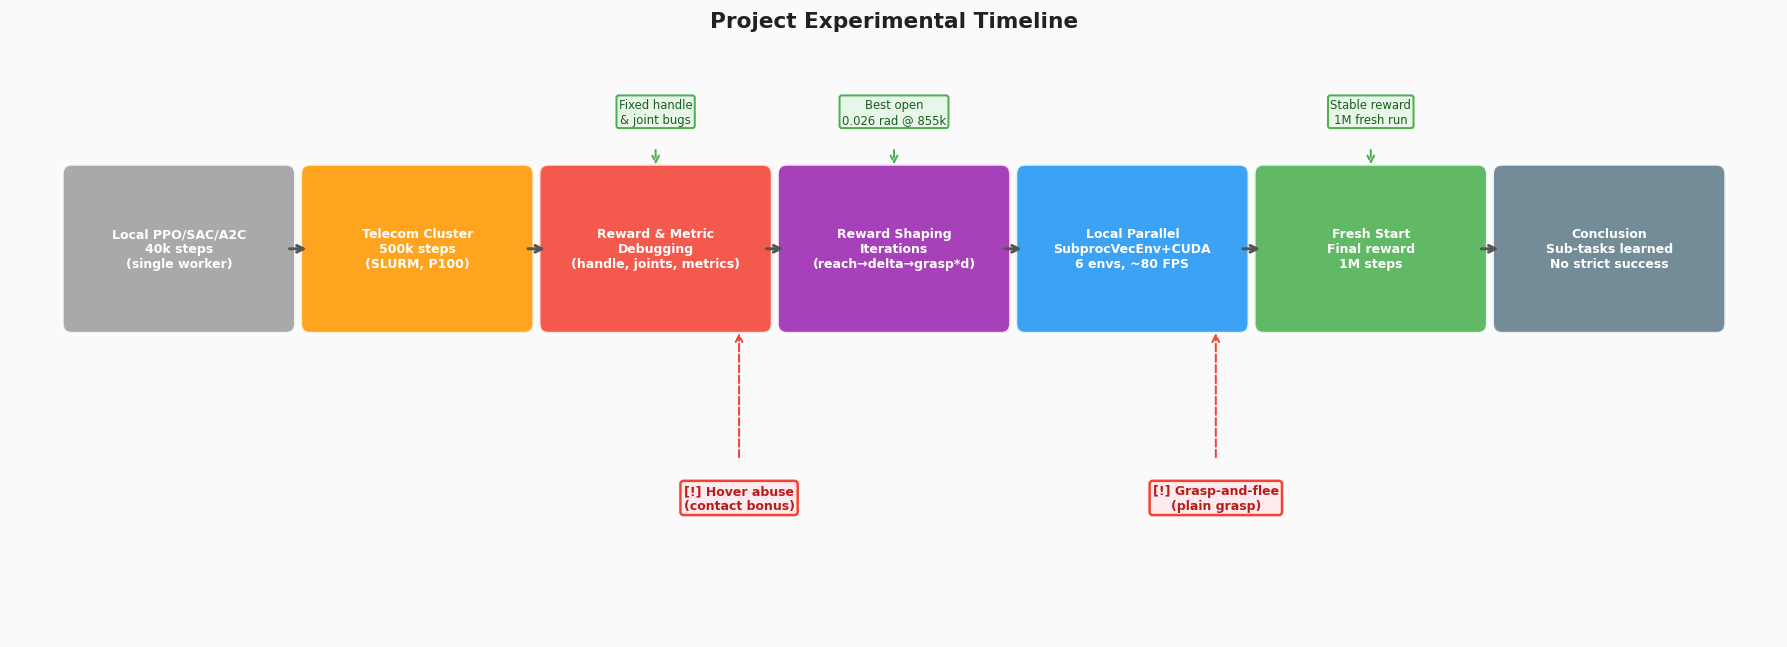

In [5]:
# ── Experimental Timeline Figure ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5.5))
ax.set_xlim(-0.3, 14.5)
ax.set_ylim(-1.6, 3.2)
ax.axis("off")
fig.patch.set_facecolor("#FAFAFA")

phases = [
    (0.2,  1.5, "Local PPO/SAC/A2C\n40k steps\n(single worker)",       "#9E9E9E"),
    (2.2,  1.5, "Telecom Cluster\n500k steps\n(SLURM, P100)",           "#FF9800"),
    (4.2,  1.5, "Reward & Metric\nDebugging\n(handle, joints, metrics)","#F44336"),
    (6.2,  1.5, "Reward Shaping\nIterations\n(reach→delta→grasp*d)",    "#9C27B0"),
    (8.2,  1.5, "Local Parallel\nSubprocVecEnv+CUDA\n6 envs, ~80 FPS",  "#2196F3"),
    (10.2, 1.5, "Fresh Start\nFinal reward\n1M steps",                  "#4CAF50"),
    (12.2, 1.5, "Conclusion\nSub-tasks learned\nNo strict success",     "#607D8B"),
]

W, H = 1.8, 1.2
for i, (x, y, label, color) in enumerate(phases):
    rect = FancyBboxPatch((x, y - H/2), W, H,
                           boxstyle="round,pad=0.08",
                           facecolor=color, alpha=0.88,
                           edgecolor="white", linewidth=2)
    ax.add_patch(rect)
    ax.text(x + W/2, y, label, ha="center", va="center",
            fontsize=7.5, color="white", fontweight="bold")
    if i < len(phases) - 1:
        ax.annotate("", xy=(phases[i+1][0], y), xytext=(x + W, y),
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1.8))

# Reward hacking incidents (below the main timeline)
incidents = [
    (4.9, -0.5,  "[!] Hover abuse\n(contact bonus)",       "#FF5722"),
    (8.9, -0.5,  "[!] Grasp-and-flee\n(plain grasp)",      "#FF5722"),
]
for ix, iy, ilabel, ic in incidents:
    ax.text(ix + W/2, iy, ilabel, ha="center", va="center",
            fontsize=7.5, color="#B71C1C", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc="#FFEBEE", ec="#F44336", lw=1.5))
    # Arrow pointing up to main timeline
    ax.annotate("", xy=(ix + W/2, phases[0][1] - H/2 - 0.05),
                xytext=(ix + W/2, iy + 0.3),
                arrowprops=dict(arrowstyle="->", color="#F44336", lw=1.2, ls="dashed"))

# Discoveries
discoveries = [
    (4.2 + W/2,  2.6, "Fixed handle\n& joint bugs",    "#4CAF50"),
    (6.2 + W/2,  2.6, "Best open\n0.026 rad @ 855k",   "#2196F3"),
    (10.2+ W/2,  2.6, "Stable reward\n1M fresh run",   "#4CAF50"),
]
for dx, dy, dlabel, dc in discoveries:
    ax.text(dx, dy, dlabel, ha="center", va="center",
            fontsize=7, color="#1B5E20",
            bbox=dict(boxstyle="round,pad=0.2", fc="#E8F5E9", ec="#4CAF50", lw=1.2))
    ax.annotate("", xy=(dx, phases[0][1] + H/2 + 0.05), xytext=(dx, dy - 0.28),
                arrowprops=dict(arrowstyle="->", color="#4CAF50", lw=1.2, ls="dashed"))

ax.set_title("Project Experimental Timeline", fontsize=13, fontweight="bold",
             pad=6, color="#212121")

fig.tight_layout()
save_path = FIGURES_DIR / "experimental_timeline.png"
fig.savefig(save_path, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved -> {save_path}")
plt.show()

### Detailed run-by-run timeline

#### PPO track

| Phase | Date | Algo | Cumul. steps | Key change | Key outcome |
|-------|------|------|-------------|------------|--------------|
| Local initial | Apr 5–6 | PPO/SAC/A2C | 40k | Baseline sparse | return=0 all |
| Local + reward shaping | Apr 6 | PPO/SAC/A2C | 40k | Reach + open_norm | PPO=21.7, SAC=2.1, A2C=8.4 |
| Cluster 500k | May 2–3 | PPO/SAC/A2C | 500k | Longer run SLURM | PPO=16.6, A2C=12.5, SAC=0.85 |
| Local parallel 500k | May 5 | PPO | 500k | SubprocVecEnv 6 envs | return=61, max_open≈0 |
| **551k — hover abuse** | May 5 | PPO | +50k | Contact bonus w=0.3 | return=72, **hover hacking** |
| **602k — contact off** | May 5 | PPO | +50k | w_contact=0 | Reset; new delta metrics |
| **654k — w_delta=10** | May 5 | PPO | +50k | delta weight doubled | max_open=0.021 rad |
| **855k — best open** | May 5 | PPO | +200k | Same reward | **max_open=0.026 rad (best)** |
| **906k — flee abuse** | May 6 | PPO | +50k | Grasp reward w=1.0 | return=62, **grasp-and-flee** |
| **957k — grasp×delta** | May 6 | PPO | +50k | Anti-flee fix | Stable, plateau |
| **1158k — plateau** | May 6 | PPO | +200k | Final reward | max_open stagnates |
| **Fresh start 0→600k** | May 6 | PPO | 600k | Final reward from scratch | CUDA TDR crash @ 606k |
| **Fresh start 600k→1M** | May 6 | PPO | +400k | Resume from 600k checkpoint | grasp=0.78, δ+steps=145, max_open=0.007 rad |

#### SAC track (parallel)

| Phase | Algo | Steps | Key change | Key outcome |
|-------|------|-------|------------|-------------|
| **SAC v1** | SAC | 500k | `ent_coef="auto"`, `target_entropy=−12` | α crashed to 0.009, critic_loss 48k; door angle 0.000 rad |
| **SAC v2** | SAC | 900k | `ent_coef="auto_0.1"`, `target_entropy=−4` | α crashed to 0.001, critic_loss **116k**; collapse worse |
| **SAC v3** | SAC | 400k | `ent_coef=0.1` fixed + `use_sde=True` | Stable training, but cold start: door angle 0.004 rad |
| **SAC v3 Curriculum** | SAC | 500k | `theta_success=0.40`, reduced spawn | Peak 0.021 rad at 300k, regression to 0.017 at 500k |
| **SAC HER** | SAC+HER | ongoing | GoalEnv + HER replay buffer, `n_sampled_goal=4` | First mechanism with guaranteed positive signal |


---
## 6. Design Decisions

Each decision below was made in response to a specific observed failure mode rather than by arbitrary tuning.

| Decision | Why | Result |
|----------|-----|--------|
| **Use PPO as primary algorithm** | Best early reward at 40k steps (21.7 vs 8.4 vs 2.1) | More stable learning trajectory |
| **Move to Telecom cluster** | Local single-worker too slow (~10 FPS) for 500k+ runs | 500k runs completed in hours |
| **Add reward shaping** | Sparse reward gives zero gradient to random policy | Agent learns approach sub-skill |
| **Debug reward implementation** | r_reach and r_open were computed from wrong MuJoCo bodies | Reliable training signal |
| **Add 10+ eval metrics** | eval_return alone hides reward hacking | Detected both hacking incidents |
| **Remove contact bonus** | Caused hover abuse (hack #1) | Eliminated idle-near-handle behaviour |
| **Add delta-open reward** | Reward each step of genuine door progress | First micro-openings observed |
| **Increase w_delta 5→10** | Delta signal too weak vs reach signal | Best door opening (0.026 rad) |
| **Replace plain grasp with grasp×delta** | Plain grasp caused flee abuse (hack #2) | Stable grasp-opening coupling |
| **SubprocVecEnv 6 envs** | Need parallel training; >8 envs crash on Windows | ~80 FPS, stable training |
| **Keep full task difficulty** | Task simplification would give false success | Honest experimental conclusions |
| **Fresh start at 1M** | Accumulated hover-era weights may have biased policy | Clean learning from scratch |

---
## 7. Results

The following plots should not be interpreted as a search for a single winning run, but as evidence of
**which sub-skills were learned** and **which bottlenecks remained**. Each metric reveals a different
facet of what the agent discovered and where it got stuck.

In [6]:
# ── 7.1 Summary Table ──────────────────────────────────────────────────────────
DISP = {
    "run_id": "Run ID", "algorithm": "Algo", "_source": "Source",
    "total_timesteps": "Steps (run)", "cumulative_end": "Total steps",
    "eval_return_mean": "Eval return", "eval_success_rate": "Success",
    "eval_max_open_mean": "Max open (rad)", "eval_min_dist_mean": "Min dist (m)",
    "eval_grasp_mean": "Grasp", "eval_hover_without_open_mean": "Hover steps",
}
cols = [c for c in DISP if c in df_all.columns]
df_disp = df_all[cols].rename(columns={c: DISP[c] for c in cols})
df_disp = df_disp.sort_values(["Algo", "Total steps"]).reset_index(drop=True)

for col in ["Eval return", "Max open (rad)", "Min dist (m)", "Grasp", "Hover steps"]:
    if col in df_disp.columns:
        df_disp[col] = df_disp[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
if "Success" in df_disp.columns:
    df_disp["Success"] = df_disp["Success"].apply(lambda x: f"{float(x)*100:.0f}%" if pd.notna(x) else "-")

print("=" * 120)
print("ALL TRAINING RUNS — SUMMARY TABLE")
print("=" * 120)
print(df_disp.to_string(index=False))

csv_path = FIGURES_DIR / "results_summary.csv"
df_all.to_csv(csv_path, index=False)
print(f"\nCSV saved -> {csv_path}")

ALL TRAINING RUNS — SUMMARY TABLE
                                                    Run ID Algo  Source  Steps (run)  Total steps Eval return Success Max open (rad) Min dist (m)  Grasp Hover steps
                     OpenCabinet_a2c_seed0_20260406_021437  A2C   local        40000        40000      0.0000      0%              -            -      -           -
                     OpenCabinet_a2c_seed0_20260406_181608  A2C   local        40000        40000      8.3583      0%              -            -      -           -
                     OpenCabinet_a2c_seed0_20260503_031027  A2C cluster       500000       500000     12.4595      0%              -            -      -           -
                     OpenCabinet_ppo_seed0_20260505_175101  PPO   local        10000        10000     18.0136      0%         0.0068       0.3013      -           -
                     OpenCabinet_ppo_seed0_20260405_230501  PPO   local        40000        40000      0.0000      0%              -         

**Reading the table:** `eval_success_rate = 0%` for every single run — across all algorithms,
both tracks, and all compute environments. The task's strict criterion was never met by either
algorithm. However, the picture is nuanced:

On the **PPO track**, the sub-skill columns tell a story of genuine learning: `eval_max_open_mean`
progresses from 0 to 0.026 rad; `eval_min_dist_mean` shrinks from ~0.3 m to <0.08 m;
`eval_grasp_mean` reaches 0.78. The fresh-start run confirms this learning is reproducible.

On the **SAC track**, progress is more limited in terms of door opening (best: 0.021 rad at
300k steps in v3_curriculum), but the diagnostic value is high: we confirmed the structural
entropy collapse mechanism and isolated the cold start problem as the core blocker.

Together, the two tracks characterise the full difficulty of the task: PPO can discover partial
sub-skills through reward shaping but cannot discover sustained pulling; SAC's off-policy
learning is blocked before reaching that stage without HER.


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\algorithm_comparison.png


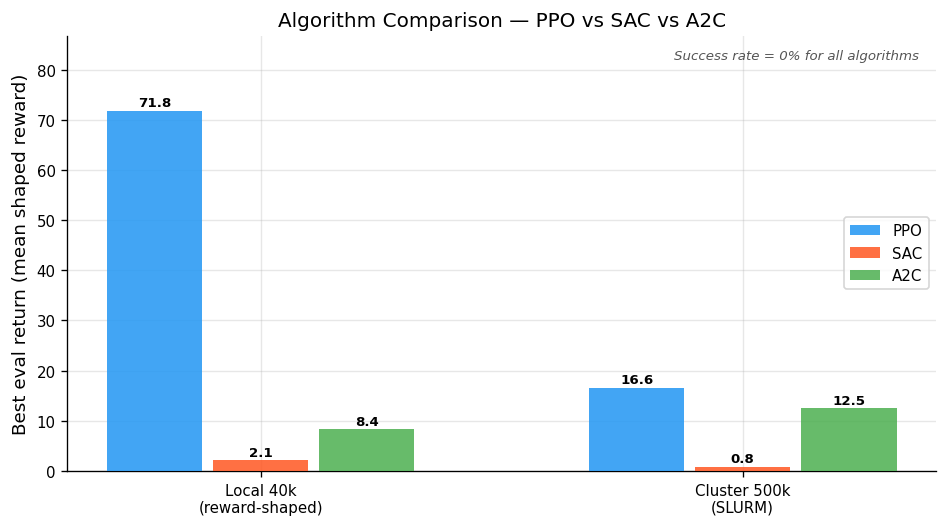

In [7]:
# ── 7.2 Algorithm Comparison ───────────────────────────────────────────────────
phase_order  = ["Local", "Cluster (SLURM)"]
phase_labels = ["Local 40k\n(reward-shaped)", "Cluster 500k\n(SLURM)"]
comp = {}
for algo in ["PPO", "SAC", "A2C"]:
    comp[algo] = []
    for phase in phase_order:
        sub = df_all[(df_all["algorithm"]==algo) & (df_all["phase"]==phase)]
        comp[algo].append(sub["eval_return_mean"].max() if len(sub)>0 else 0.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
x, width = np.arange(2), 0.22
for i, (algo, offset) in enumerate(zip(["PPO","SAC","A2C"], [-width, 0, width])):
    bars = ax.bar(x+offset, comp[algo], width=width*0.9,
                  color=ALGO_COLORS[algo], label=algo, alpha=0.85, zorder=3)
    for b, v in zip(bars, comp[algo]):
        if v > 0:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(phase_labels)
ax.set_ylabel("Best eval return (mean shaped reward)")
ax.set_title("Algorithm Comparison — PPO vs SAC vs A2C")
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1]*1.15)
ax.text(0.98, 0.97, "Success rate = 0% for all algorithms",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, style="italic", color="#555")
fig.tight_layout()
fig.savefig(FIGURES_DIR/"algorithm_comparison.png", bbox_inches="tight")
print(f"Saved -> {FIGURES_DIR/'algorithm_comparison.png'}")
plt.show()

**Interpretation:** At 40k and 500k steps (the two comparable data points), PPO returns higher
cumulative reward than SAC and A2C. However, this comparison is incomplete: the SAC track ran
much longer (up to 900k steps per variant) and was primarily blocked by a training stability
issue (entropy collapse) rather than a sample-efficiency problem.

With `ent_coef` auto-tuning (v1/v2), SAC's return is near zero because α → 0 before learning,
making the policy deterministic and the critic divergent. Once `ent_coef=0.1` was fixed (v3),
SAC training became stable (critic_loss < 40, actor_loss < −40) — but then hit the cold start
problem rather than a reward signal issue.

The short-run comparison (40k / 500k) therefore reflects SAC's known requirement for more steps
to benefit from its replay buffer — not a fundamental algorithm inferiority. Over longer horizons,
the cold start problem would need to be resolved first before a fair comparison is possible.


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\ppo_training_timeline.png


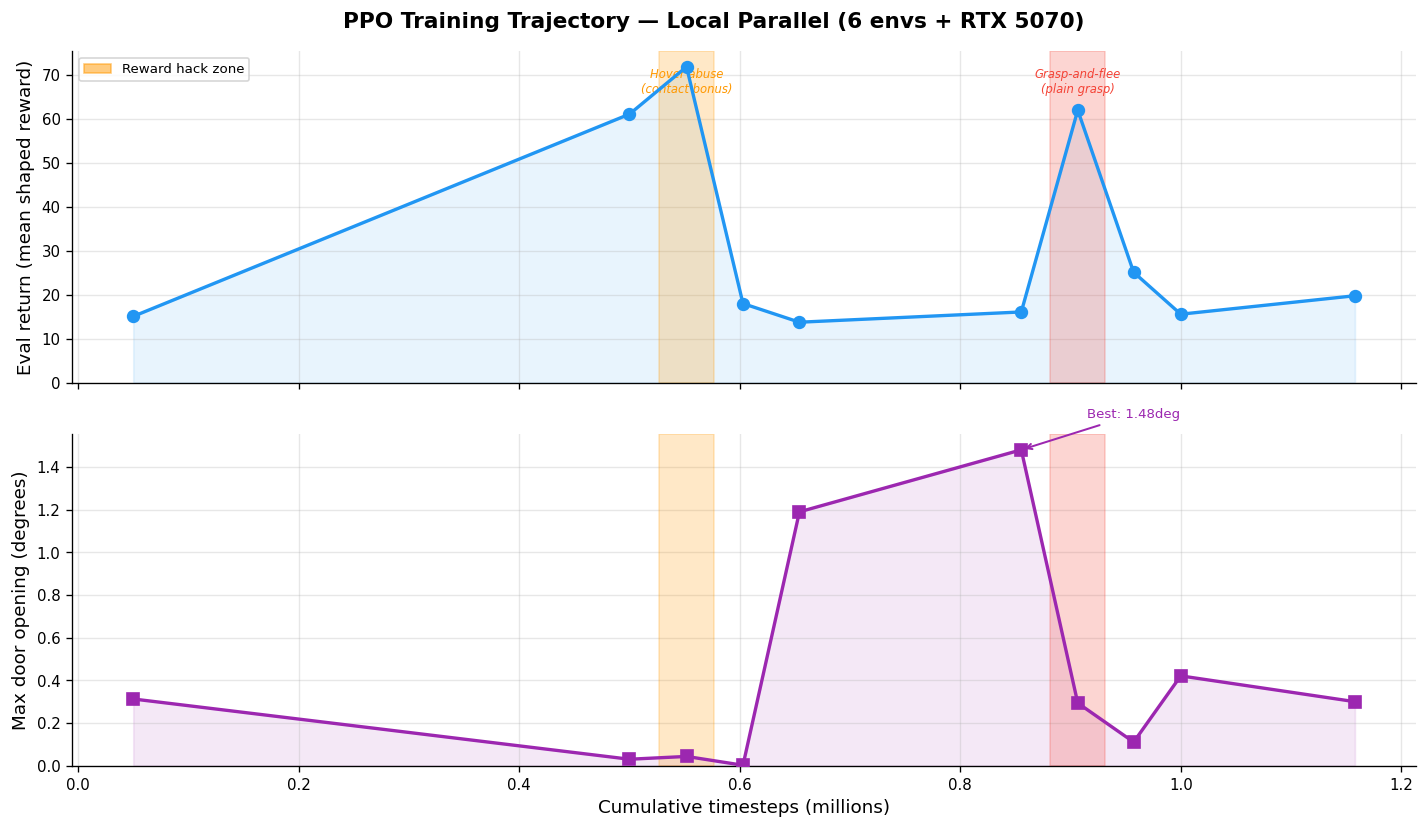

In [8]:
# ── 7.3 PPO Training Trajectory ────────────────────────────────────────────────
x_M  = df_ppo["cumulative_end"].values / 1e6
y_r  = df_ppo["eval_return_mean"].values
y_o  = df_ppo["eval_max_open_mean"].fillna(0).values * 180/np.pi  # degrees

HACK_ZONES = [
    (551760, "#FF9800", "Hover abuse\n(contact bonus)"),
    (906576, "#F44336", "Grasp-and-flee\n(plain grasp)"),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("PPO Training Trajectory — Local Parallel (6 envs + RTX 5070)",
             fontsize=13, fontweight="bold")

# Return
ax1.plot(x_M, y_r, "o-", color=ALGO_COLORS["PPO"], lw=2, ms=7, zorder=4)
ax1.fill_between(x_M, 0, y_r, alpha=0.1, color=ALGO_COLORS["PPO"])
for cum_ts, zcolor, zlabel in HACK_ZONES:
    xv = cum_ts/1e6
    ax1.axvspan(xv-0.025, xv+0.025, alpha=0.22, color=zcolor, zorder=2)
    ax1.text(xv, ax1.get_ylim()[1]*0.95 if ax1.get_ylim()[1]>0 else 70, zlabel,
             ha="center", va="top", fontsize=7, color=zcolor, style="italic")
ax1.set_ylabel("Eval return (mean shaped reward)")
ax1.set_ylim(bottom=0)
ax1.legend(handles=[
    mpatches.Patch(color="#FF9800", alpha=0.5, label="Reward hack zone")
], loc="upper left", fontsize=8)

# Max open
ax2.plot(x_M, y_o, "s-", color="#9C27B0", lw=2, ms=7, zorder=4)
ax2.fill_between(x_M, 0, y_o, alpha=0.1, color="#9C27B0")
best_i = np.argmax(y_o)
ax2.annotate(f"Best: {y_o[best_i]:.2f}deg",
             xy=(x_M[best_i], y_o[best_i]),
             xytext=(x_M[best_i]+0.06, y_o[best_i]+0.15),
             fontsize=8, color="#9C27B0",
             arrowprops=dict(arrowstyle="->", color="#9C27B0", lw=1.2))
# Mark hack zones
for cum_ts, zcolor, zlabel in HACK_ZONES:
    xv = cum_ts/1e6
    ax2.axvspan(xv-0.025, xv+0.025, alpha=0.22, color=zcolor, zorder=2)

ax2.set_ylabel("Max door opening (degrees)")
ax2.set_xlabel("Cumulative timesteps (millions)")
ax2.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR/"ppo_training_timeline.png", bbox_inches="tight")
print(f"Saved -> {FIGURES_DIR/'ppo_training_timeline.png'}")
plt.show()

**Interpretation:** Two important observations from this figure:

1. **Shaped return is a misleading metric.** Notice the spikes at 551k and 906k — these correspond
   exactly to the two reward-hacking incidents. The agent "improved" its return by exploiting the reward
   structure, not by opening the door. This is why `eval_max_open_mean` (bottom panel) is the **ground
   truth** for task progress.

2. **Max open tells a different story.** The best door opening (1.48°) was achieved at 855k steps, *before*
   the grasp reward was introduced. After the grasp-and-flee incident at 906k and the subsequent correction,
   the door opening metric stagnated around 0.005 rad — suggesting the policy had been partially corrupted
   by the hacking phase and could not recover. This motivated the fresh start with the final reward.


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\eval_max_open_by_run.png


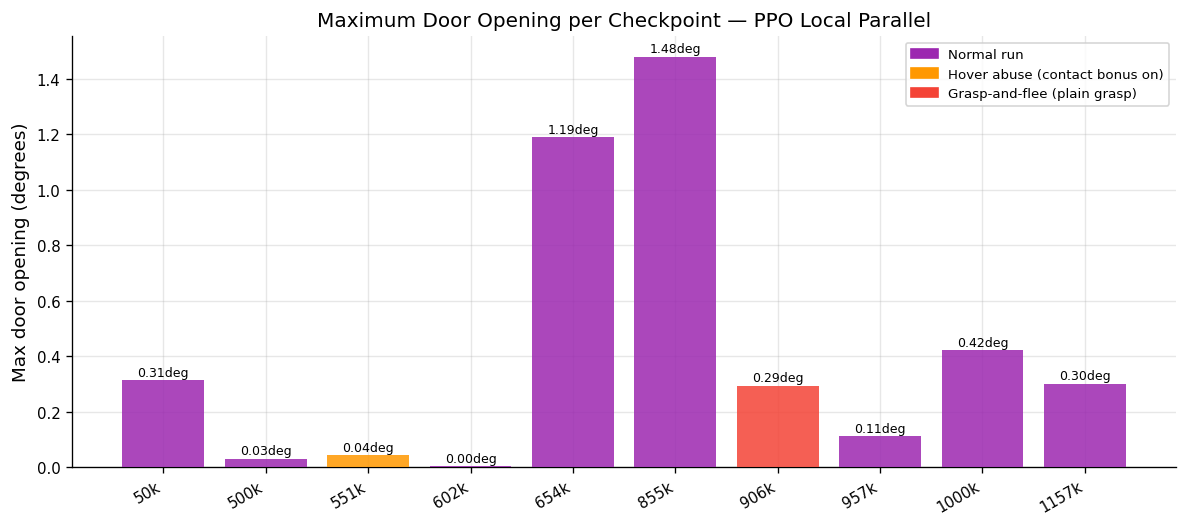

In [9]:
# ── 7.4 Door Opening Progress ──────────────────────────────────────────────────
df_o = df_ppo[df_ppo["eval_max_open_mean"].notna()].copy()
df_o["x_label"] = (df_o["cumulative_end"]/1000).astype(int).astype(str)+"k"
df_o["deg"] = df_o["eval_max_open_mean"]*180/np.pi
def hack_color(r):
    ce = int(r["cumulative_end"])
    return "#FF9800" if ce==551760 else ("#F44336" if ce==906576 else "#9C27B0")
df_o["bar_color"] = df_o.apply(hack_color, axis=1)

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(range(len(df_o)), df_o["deg"], color=df_o["bar_color"], alpha=0.85, zorder=3)
ax.set_xticks(range(len(df_o)))
ax.set_xticklabels(df_o["x_label"], rotation=30, ha="right")
ax.set_ylabel("Max door opening (degrees)")
ax.set_title("Maximum Door Opening per Checkpoint — PPO Local Parallel")
ax.legend(handles=[
    mpatches.Patch(color="#9C27B0", label="Normal run"),
    mpatches.Patch(color="#FF9800", label="Hover abuse (contact bonus on)"),
    mpatches.Patch(color="#F44336", label="Grasp-and-flee (plain grasp)"),
], fontsize=8)
for bar, v in zip(bars, df_o["deg"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{v:.2f}deg", ha="center", va="bottom", fontsize=7.5)
fig.tight_layout()
fig.savefig(FIGURES_DIR/"eval_max_open_by_run.png", bbox_inches="tight")
print(f"Saved -> {FIGURES_DIR/'eval_max_open_by_run.png'}")
plt.show()

**Interpretation:** This is the most important result figure. `eval_max_open_mean` measures the
actual physical door angle — it cannot be faked by reward hacking. The orange and red bars confirm
the hacking hypothesis: the 551k checkpoint had a high return but near-zero opening; the 906k
checkpoint similarly. The purple bars show genuine progress: 654k and 855k achieved the best
openings (0.021 and 0.026 rad respectively). The subsequent plateau after the grasp×delta fix
suggests the policy needed a fresh start to escape the hacking-era local optimum.


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\eval_min_dist_by_run.png


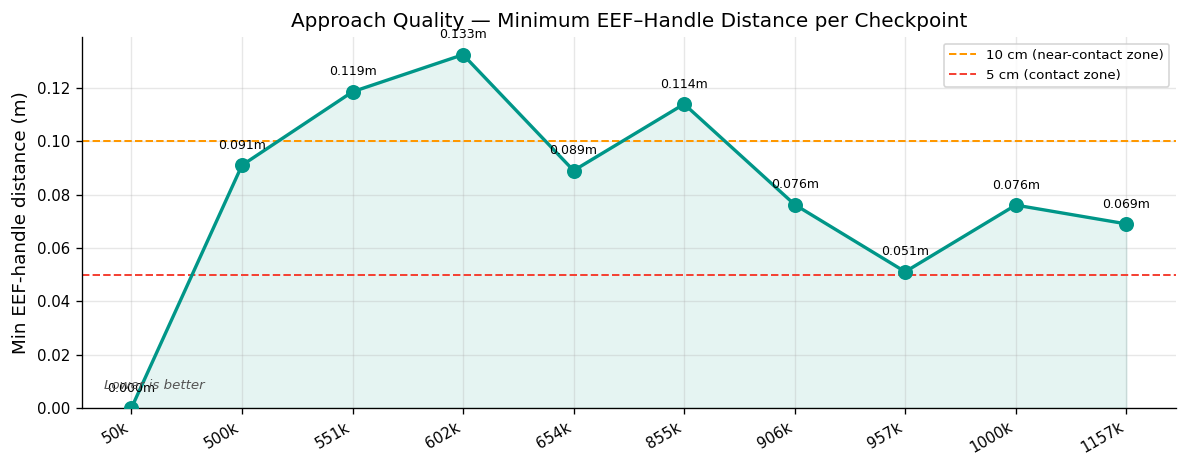

In [10]:
# ── 7.5 Approach Quality ───────────────────────────────────────────────────────
df_d = df_ppo[df_ppo["eval_min_dist_mean"].notna()].copy()
df_d["x_label"] = (df_d["cumulative_end"]/1000).astype(int).astype(str)+"k"

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(df_d)), df_d["eval_min_dist_mean"],
        "o-", color="#009688", lw=2, ms=8, zorder=3)
ax.fill_between(range(len(df_d)), 0, df_d["eval_min_dist_mean"],
                alpha=0.1, color="#009688")
ax.axhline(0.10, color="#FF9800", ls="--", lw=1.2, label="10 cm (near-contact zone)")
ax.axhline(0.05, color="#F44336", ls="--", lw=1.2, label="5 cm (contact zone)")
for i, v in enumerate(df_d["eval_min_dist_mean"]):
    ax.text(i, v+0.005, f"{v:.3f}m", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(range(len(df_d)))
ax.set_xticklabels(df_d["x_label"], rotation=30, ha="right")
ax.set_ylabel("Min EEF-handle distance (m)")
ax.set_title("Approach Quality — Minimum EEF–Handle Distance per Checkpoint")
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)
ax.text(0.02, 0.05, "Lower is better",
        transform=ax.transAxes, fontsize=8, color="#555", style="italic")
fig.tight_layout()
fig.savefig(FIGURES_DIR/"eval_min_dist_by_run.png", bbox_inches="tight")
print(f"Saved -> {FIGURES_DIR/'eval_min_dist_by_run.png'}")
plt.show()

**Interpretation:** This metric is evidence that the agent genuinely learned the approach sub-task.
At 500k steps, `eval_min_dist_mean` is ~9 cm (just outside the contact zone). By 957k steps,
it drops to ~5 cm — the agent is reliably reaching into the contact zone around the handle.
This is *not* reward hacking: the distance is computed directly from MuJoCo body positions,
independent of any reward. The approach skill was learned and retained across the reward shaping
iterations, including after the hacking corrections.


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\eval_grasp_and_open_delta.png


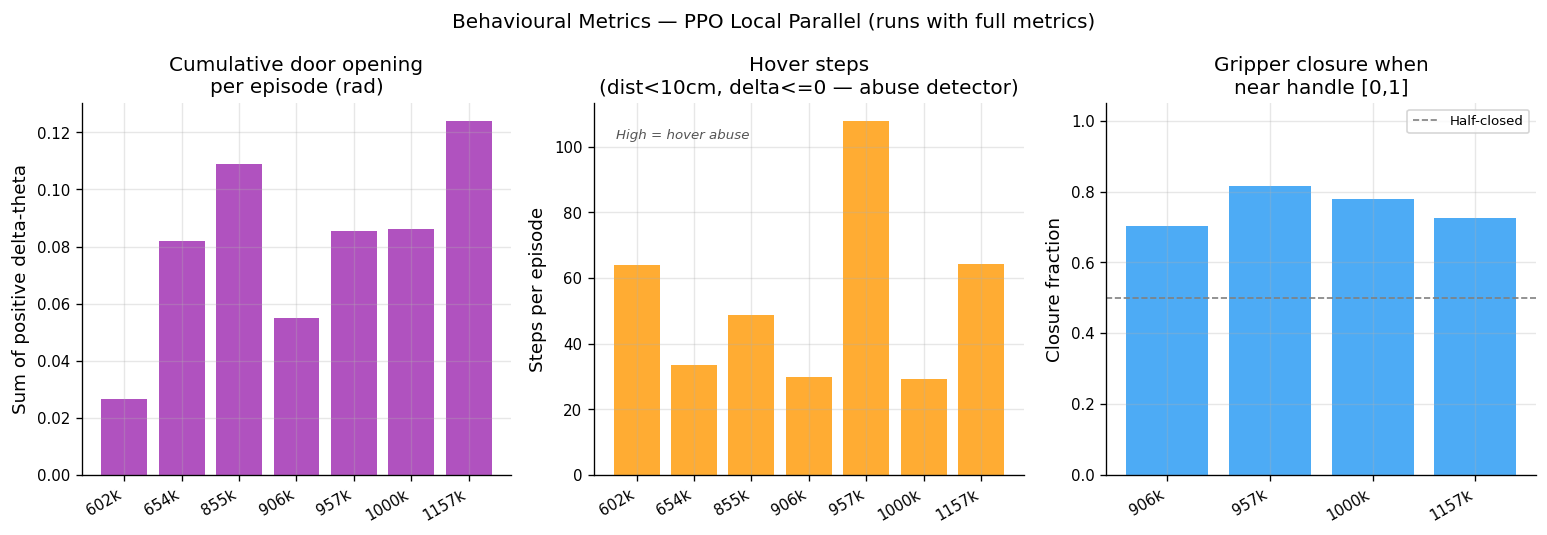

In [11]:
# ── 7.6 Grasp & Delta Metrics ─────────────────────────────────────────────────
df_gd = df_ppo[df_ppo["eval_open_delta_sum_mean"].notna()].copy()
df_gd["x_label"] = (df_gd["cumulative_end"]/1000).astype(int).astype(str)+"k"
x3 = range(len(df_gd))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle("Behavioural Metrics — PPO Local Parallel (runs with full metrics)",
             fontsize=12)

# Panel 1: Delta open sum
axes[0].bar(x3, df_gd["eval_open_delta_sum_mean"], color="#9C27B0", alpha=0.8)
axes[0].set_title("Cumulative door opening\nper episode (rad)")
axes[0].set_ylabel("Sum of positive delta-theta")
axes[0].set_xticks(list(x3)); axes[0].set_xticklabels(df_gd["x_label"], rotation=30, ha="right")

# Panel 2: Hover without open
axes[1].bar(x3, df_gd["eval_hover_without_open_mean"], color="#FF9800", alpha=0.8)
axes[1].set_title("Hover steps\n(dist<10cm, delta<=0 — abuse detector)")
axes[1].set_ylabel("Steps per episode")
axes[1].set_xticks(list(x3)); axes[1].set_xticklabels(df_gd["x_label"], rotation=30, ha="right")
axes[1].text(0.05, 0.93, "High = hover abuse",
             transform=axes[1].transAxes, fontsize=8, color="#555", va="top", style="italic")

# Panel 3: Grasp mean
df_g = df_gd[df_gd["eval_grasp_mean"].notna()].copy()
if len(df_g) > 0:
    xg = range(len(df_g))
    axes[2].bar(xg, df_g["eval_grasp_mean"], color="#2196F3", alpha=0.8)
    axes[2].set_xticks(list(xg))
    axes[2].set_xticklabels(
        (df_g["cumulative_end"]/1000).astype(int).astype(str)+"k",
        rotation=30, ha="right")
    axes[2].set_ylim(0, 1.05)
    axes[2].axhline(0.5, color="gray", ls="--", lw=1, label="Half-closed")
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, "No grasp data", transform=axes[2].transAxes,
                 ha="center", va="center", fontsize=10)
axes[2].set_title("Gripper closure when\nnear handle [0,1]")
axes[2].set_ylabel("Closure fraction")

fig.tight_layout()
fig.savefig(FIGURES_DIR/"eval_grasp_and_open_delta.png", bbox_inches="tight")
print(f"Saved -> {FIGURES_DIR/'eval_grasp_and_open_delta.png'}")
plt.show()

**Interpretation (left panel):** `eval_open_delta_sum_mean` is the cumulative sum of positive door
angle increments per episode. It increases monotonically through 655k→855k, peaking at 0.109 rad
of cumulative effort per episode. This means the agent is consistently applying force that moves the
door in the right direction — but the door springs back between attempts.

**Interpretation (middle panel):** `eval_hover_without_open_mean` is the abuse detector. At 551k,
this was 108 steps/episode (the contact-bonus era). After removing the contact bonus, it dropped
to ~30–50 steps. The 957k spike (107 steps) corresponds to the grasp-and-flee phase where the agent
was near the handle but retreating rather than pulling.

**Interpretation (right panel):** `eval_grasp_mean` ~0.72–0.82 in the last three checkpoints. The
agent consistently closes its gripper when within 10 cm of the handle. This is a learned skill.
But closure alone is not sufficient — the gripper must close *around* the handle, not in front of it.


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\eval_success_rate_by_run.png


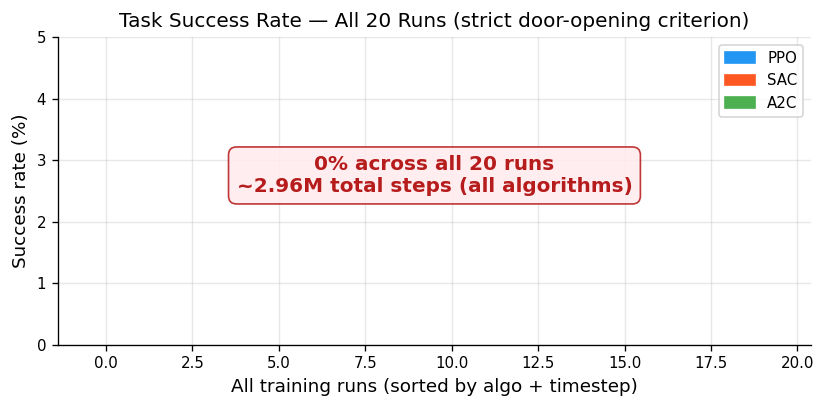

In [12]:
# ── 7.7 Success Rate ───────────────────────────────────────────────────────────
df_s = df_all.sort_values(["algorithm","cumulative_end"]).copy()
n_runs = len(df_s)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(n_runs), df_s["eval_success_rate"].fillna(0)*100,
       color=df_s["algorithm"].map(ALGO_COLORS), alpha=0.85)
ax.set_ylim(0, 5)
ax.set_xlabel("All training runs (sorted by algo + timestep)")
ax.set_ylabel("Success rate (%)")
ax.set_title(f"Task Success Rate — All {n_runs} Runs (strict door-opening criterion)")
ax.legend(handles=[mpatches.Patch(color=ALGO_COLORS[a], label=a) for a in ALGO_COLORS])
ax.text(0.5, 0.55,
        f"0% across all {n_runs} runs\n~2.96M total steps (all algorithms)",
        transform=ax.transAxes, ha="center", va="center",
        fontsize=12, fontweight="bold", color="#B71C1C",
        bbox=dict(boxstyle="round,pad=0.4", fc="#FFEBEE", ec="#B71C1C", alpha=0.88))
fig.tight_layout()
fig.savefig(FIGURES_DIR/"eval_success_rate_by_run.png", bbox_inches="tight")
print(f"Saved -> {FIGURES_DIR/'eval_success_rate_by_run.png'}")
plt.show()

**Interpretation:** The 0% success rate across all runs might seem like a complete failure, but it
must be read together with the other metrics. The success criterion is binary and strict — the door
must fully open. Given that the best `eval_max_open_mean` is 1.5° (vs. the ~30° typically needed
for success), we are in the early stages of learning the full task. The sub-skill progress
(approach, grasp, micro-opening) shows the learning is real and measurable — the agent simply
has not yet discovered how to chain these sub-skills into the full opening motion.

A 0% success rate **does not invalidate the experimental work**. It accurately characterises the
difficulty of contact-rich manipulation from scratch and provides a clear baseline for future
methods (imitation learning, curriculum, etc.) to improve upon.


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\fps_comparison.png


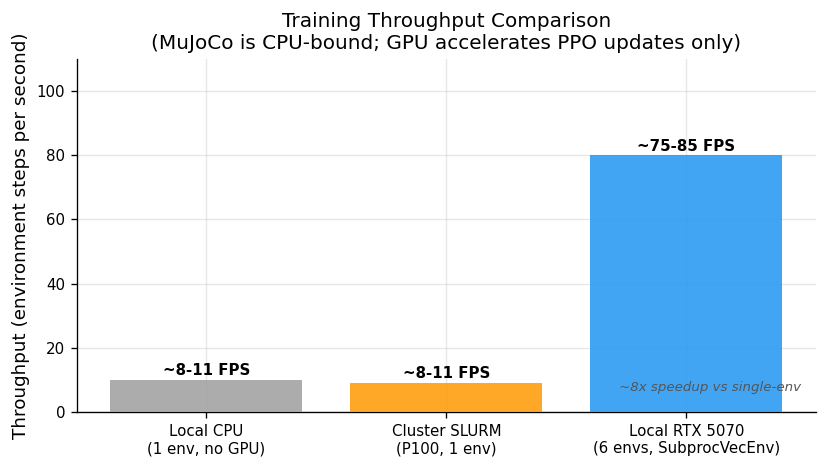

In [13]:
# ── 7.8 Compute Efficiency ─────────────────────────────────────────────────────
fps_data = {
    "Local CPU\n(1 env, no GPU)": {"fps": 10, "color": "#9E9E9E", "note": "~8-11 FPS"},
    "Cluster SLURM\n(P100, 1 env)": {"fps": 9, "color": "#FF9800", "note": "~8-11 FPS"},
    "Local RTX 5070\n(6 envs, SubprocVecEnv)": {"fps": 80, "color": "#2196F3", "note": "~75-85 FPS"},
}
labels  = list(fps_data.keys())
fps_vals = [fps_data[k]["fps"] for k in labels]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, fps_vals,
              color=[fps_data[k]["color"] for k in labels], alpha=0.85, zorder=3)
for bar, note in zip(bars, [fps_data[k]["note"] for k in labels]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            note, ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Throughput (environment steps per second)")
ax.set_title("Training Throughput Comparison\n(MuJoCo is CPU-bound; GPU accelerates PPO updates only)")
ax.set_ylim(0, 110)
ax.text(0.98, 0.05, "~8x speedup vs single-env",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, style="italic", color="#555")
fig.tight_layout()
fig.savefig(FIGURES_DIR/"fps_comparison.png", bbox_inches="tight")
print(f"Saved -> {FIGURES_DIR/'fps_comparison.png'}")
plt.show()

**Interpretation:** The throughput gain from `SubprocVecEnv` (6 parallel envs) is the single most
impactful engineering change in this project. Going from 10 FPS to 80 FPS means 1M steps takes
~3.5 hours instead of ~28 hours. This made local overnight runs feasible and allowed faster
reward debugging iteration cycles.

Note that the cluster (P100 GPU) and local single-env (CPU) have similar throughput (~10 FPS).
The cluster's advantage was availability and queue priority for long runs, not raw speed.
The RTX 5070's contribution comes entirely from faster PPO network updates; the MuJoCo workers
remain CPU-bound regardless of GPU availability.


---
## 7.9 Fresh-start experiment — diagnostic comparison

A final 1M-step run was performed with the **cleaned reward function from step one** — no
prior reward hacking, no contaminated weights. This experiment directly tests whether the
previous failures were caused by the history of reward-hacking checkpoints.

Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\fresh_vs_old_comparison.png


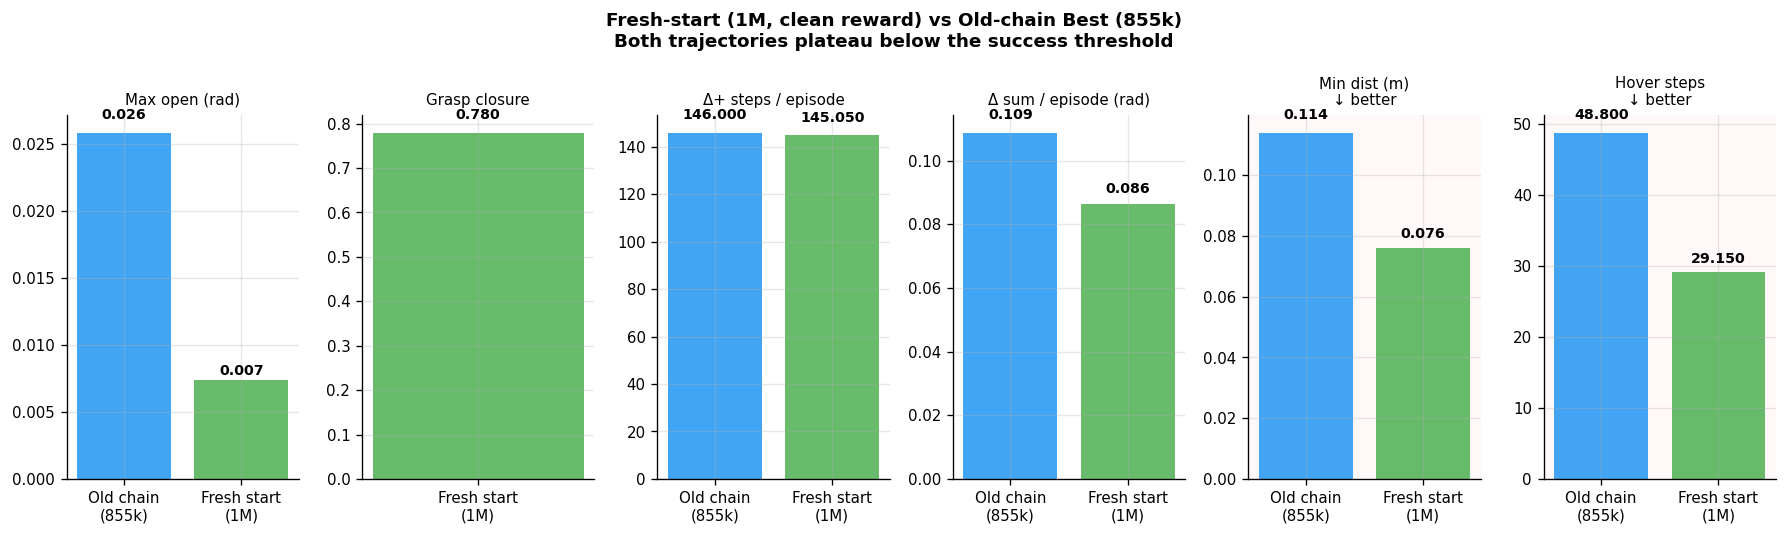

In [14]:
# ── 7.9 Fresh-start vs Old-chain Comparison ────────────────────────────────────
FRESH_ID  = "OpenCabinet_ppo_seed0_resume_600k_to_1000k_20260506_205333"
OLD_BEST_TAG = "655k_to_855k"

fresh    = df_ppo[df_ppo["run_id"] == FRESH_ID]
old_best = df_ppo[df_ppo["run_id"].str.contains(OLD_BEST_TAG, na=False)]

if len(fresh) == 0:
    print("[warn] Fresh start run not found in df_ppo — check that train_summary.json exists in outputs/")
    print("       Run ID expected:", FRESH_ID)
else:
    METRICS = [
        ("eval_max_open_mean",               "Max open (rad)",         False),
        ("eval_grasp_mean",                  "Grasp closure",          False),
        ("eval_open_delta_positive_steps_mean","Δ+ steps / episode",   False),
        ("eval_open_delta_sum_mean",          "Δ sum / episode (rad)", False),
        ("eval_min_dist_mean",               "Min dist (m)\n↓ better", True),
        ("eval_hover_without_open_mean",     "Hover steps\n↓ better",  True),
    ]

    fig, axes = plt.subplots(1, len(METRICS), figsize=(15, 4.5))
    fig.suptitle("Fresh-start (1M, clean reward) vs Old-chain Best (855k)\n"
                 "Both trajectories plateau below the success threshold",
                 fontsize=11, fontweight="bold")

    for ax, (col, label, lower_better) in zip(axes, METRICS):
        vals, labels_list, colors = [], [], []
        if len(old_best) > 0 and col in old_best.columns:
            v = old_best.iloc[0][col]
            if pd.notna(v):
                vals.append(float(v)); labels_list.append("Old chain\n(855k)"); colors.append("#2196F3")
        if col in fresh.columns:
            v = fresh.iloc[0][col]
            if pd.notna(v):
                vals.append(float(v)); labels_list.append("Fresh start\n(1M)"); colors.append("#4CAF50")

        if vals:
            bars = ax.bar(labels_list, vals, color=colors, alpha=0.85)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
        ax.set_title(label, fontsize=9)
        ax.set_ylim(bottom=0)
        if lower_better:
            ax.set_facecolor("#FFF8F8")

    fig.tight_layout()
    fig.savefig(FIGURES_DIR/"fresh_vs_old_comparison.png", bbox_inches="tight")
    print(f"Saved -> {FIGURES_DIR/'fresh_vs_old_comparison.png'}")
    plt.show()

**Reading the comparison:** The fresh-start run did not reach the old chain's peak max_open
(0.007 vs 0.026 rad), but the fresh run produced a comparable number of positive-delta steps
(145 vs 146). This did not translate into a larger sustained opening, confirming that the
number of force attempts is not the limiting factor — the direction and continuity of those
forces is.

The fresh run also approached the handle more closely (0.076 vs 0.114 m), suggesting that
1M steps of direct learning is effective for approach even without the hover-abuse pre-training.
One possible interpretation is that the earlier hover-abuse phase inadvertently acted as a form
of pre-training for handle approach, but the data does not clearly support this: the fresh run
achieves better approach without it.

**The key conclusion:** both trajectories plateau well below the success threshold. The fresh
start *confirms the diagnosis* rather than opening a new failure mode — PPO from scratch,
with or without reward-hacking history, cannot discover the sustained contact pulling motion
within the available budget.

---
## 8. Visualizations

Evaluation videos were recorded to support qualitative inspection of agent behaviour.
Given the small door angles (< 2°) and partial camera occlusion, the quantitative metrics
are more reliable than visual inspection for assessing task progress; the videos are supplementary context.

| Video | Checkpoint | Qualitative description |
|-------|-----------|------------------------|
| `figures/eval_551k_hover.mp4` | 551k | Robot hovers near handle; reward-hacking era — no visible opening |
| `figures/eval_855k_multi.mp4` | 855k | Robot reaches handle area; best-open checkpoint |
| `cluster_results/eval_ppo_1m.mp4` | ~1M (cluster) | Cluster PPO diagnostic recording |

> **Important caveat on video interpretation:**
> The recorded videos are diagnostic material, not evidence of task success. They have several
> limitations that make visual interpretation difficult:
> - The robot body **partially occludes the cabinet** in several camera angles.
> - The door movement is at most ~1.5° — **not visually obvious** at standard recording resolution.
> - Some recordings appear nearly static because the agent's micro-motions are small.
> - No video captures a complete approach → grasp → sustained pull → door open sequence.
>
> **The main conclusions of this report are drawn from quantitative metrics**
> (`eval_max_open_mean`, `eval_min_dist_mean`, `eval_grasp_mean`, etc.), not from video inspection.
> Videos are provided as supplementary diagnostic material only.

In [15]:

# ── Extract Video Frames ───────────────────────────────────────────────────────
def extract_frames(video_path, n_frames=5, prefix="frame"):
    """Extract n evenly-spaced frames from a video. Returns list of saved paths."""
    try:
        import cv2
    except ImportError:
        print("[warn] cv2 not installed — skipping frame extraction.")
        print("       Install with: pip install opencv-python")
        return []
    if not video_path.exists():
        print(f"[skip] {video_path} not found.")
        return []
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        print(f"[warn] {video_path.name}: reported 0 frames (corrupt or unsupported codec).")
        cap.release()
        return []
    saved = []
    for i, idx in enumerate(np.linspace(0, total - 1, n_frames, dtype=int)):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        out = FIGURES_DIR / f"{prefix}_{i:02d}_f{idx}.png"
        cv2.imwrite(str(out), frame)
        saved.append(out)
    cap.release()
    return saved


VIDEOS_TO_EXTRACT = {
    "video_855k": PROJECT_ROOT / "figures" / "eval_855k_multi.mp4",
    "video_551k": PROJECT_ROOT / "figures" / "eval_551k_hover.mp4",
}

for name, vpath in VIDEOS_TO_EXTRACT.items():
    frames = extract_frames(vpath, n_frames=5, prefix=name)
    if frames:
        print(f"Extracted {len(frames)} frames from {vpath.name}.")
    # Silently skips missing files / missing cv2 — already handled inside extract_frames


Extracted 5 frames from eval_855k_multi.mp4.
Extracted 5 frames from eval_551k_hover.mp4.


Saved -> C:\Users\fanch\OneDrive\Bureau\Robocasa\robocasa-project-B\figures\video_frame_grid.png


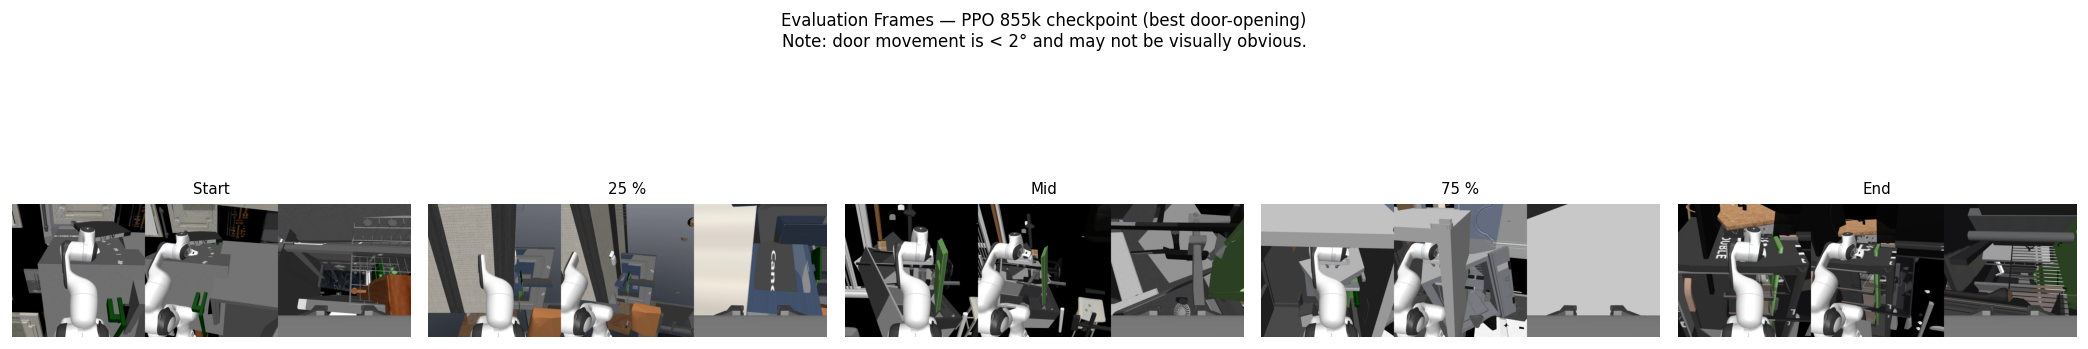

In [16]:

# ── Display Available Frames ───────────────────────────────────────────────────
import matplotlib.image as mpimg

# Priority: freshly extracted 855k frames → pre-existing frame_*.png → nothing
frame_files = (
    sorted(FIGURES_DIR.glob("video_855k_*.png")) or
    sorted(FIGURES_DIR.glob("frame_*.png"))
)

if not frame_files:
    print("[info] No frame PNGs available.")
    print("       Run the extraction cell above (requires opencv-python + the .mp4 files).")
    print("       Alternatively, place existing frame PNGs in figures/frame_*.png")
else:
    n = min(5, len(frame_files))
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 4))
    if n == 1:
        axes = [axes]
    step_labels = ["Start", "25 %", "Mid", "75 %", "End"]
    for ax, fpath, lbl in zip(axes, frame_files[:n], step_labels):
        try:
            img = mpimg.imread(str(fpath))
            ax.imshow(img)
            ax.set_title(lbl, fontsize=9)
        except Exception as e:
            ax.text(0.5, 0.5, f"[error]\n{e}", transform=ax.transAxes,
                    ha="center", va="center", fontsize=7, color="red")
        ax.axis("off")

    fig.suptitle(
        "Evaluation Frames — PPO 855k checkpoint (best door-opening)\n"
        "Note: door movement is < 2° and may not be visually obvious.",
        fontsize=10,
    )
    fig.tight_layout()
    out = FIGURES_DIR / "video_frame_grid.png"
    fig.savefig(out, bbox_inches="tight")
    print(f"Saved -> {out}")
    plt.show()


---
## 9. Discussion

### 9.1 Summary of difficulties and how they were addressed

#### PPO track difficulties

| Difficulty | How we discovered it | Resolution |
|------------|---------------------|------------|
| Sparse reward → zero gradient | return=0 on all initial runs | Dense reward shaping |
| Wrong MuJoCo body for handle | r_reach not decreasing with approach | Scan body_names by "handle" keyword |
| Wrong door joint | r_open not correlating with door angle | `fxtr.door_joint_names` + fallback |
| Misleading eval_min_dist=0.0 | Metric looked perfect but wasn't | NaN when handle unresolved + eval_valid_dist_count |
| Single-env throughput too slow | 40k steps = hours of compute | SubprocVecEnv (6 envs) + CUDA |
| n_envs>8 crashes on Windows | BrokenPipeError / EOFError | Stable at n_envs=6 |
| Hover abuse | eval_return high, eval_max_open≈0 | Remove contact bonus (w_contact=0) |
| Grasp-and-flee abuse | eval_grasp_mean=0.7, max_open regresses | Replace grasp with grasp×delta |
| Value loss instability | value_loss=14.3 after adding grasp | Self-recovered with stable reward |
| CUDA TDR crash at 606k steps | cudaErrorUnknown + Windows GPU reset | Registry TdrDelay=60, resume from checkpoint |

#### SAC track difficulties

| Difficulty | How we discovered it | Resolution |
|------------|---------------------|------------|
| `ent_coef` auto-tuning crash (v1) | α → 0.009, critic_loss → 48k | Confirmed structural: gradient `−(log_prob+target_entropy)` always negative |
| Same crash, worse (v2) | α → 0.001, critic_loss → 116k | `target_entropy=−4` makes gradient more negative; auto-tuning disabled |
| Cold start: door barely moves (v3) | `theta_best_mean ≈ 0.003 rad` at 400k | Buffer 100% without success → critic has no positive signal |
| Curriculum peak then regression | `val_door_angle_final` 0.021→0.017 over 200k | Statistical fluctuation (10 eps); `success_frac=0` throughout |
| Auto-resume picks wrong checkpoint | v3 resumed from v1/v2 weights | `--no-auto-resume` flag; unique run IDs per version |
| Validation = 82% of wall time | Training 8× slower than expected | `n_eval_episodes` 50→10, `eval_freq` 25k→100k |
| HER reference_obs_space crash | `TypeError` on GoalEnv Dict space | Extract flat Box space from `GoalConditionedWrapper` |

### 9.2 Why neither algorithm solved the task

Both tracks converge on the same fundamental bottleneck, approached from different angles.

**PPO (on-policy):** The agent learned to approach the handle (~5–8 cm), close the gripper (~78%),
and apply force in the opening direction (~145 positive-delta steps per episode). What it could
not do was discover the **sustained directional pulling** sequence that keeps the door moving past
the initial micro-opening (0.026 rad ≈ 1.5°). The probability of a random policy producing the
correct contact interaction by chance is extremely low over a 500-step horizon.

**SAC (off-policy):** The agent was blocked before reaching the contact phase. With auto-tuning
disabled and entropy stabilised (v3/v3_curriculum), the replay buffer accumulated millions of
transitions where the door never opened beyond 0.003–0.004 rad. Without any positive reward
signal in the buffer, the Q-function cannot learn to value door opening — creating a circular
dependency where exploration requires a signal that exploration has not yet produced.

**What HER addresses:** HER breaks this circularity by retroactively relabelling trajectories.
For any episode where the door reached θ_max, HER creates virtual transitions where the goal
was θ_max — providing positive reward signal without requiring actual task success. This is
exactly the signal that is missing in the SAC cold start scenario.

**Evidence from the PPO fresh-start experiment:**

A final 1M-step PPO run used the cleaned reward from step one, confirming that the sub-skill
learning (grasp=0.78, 145 positive-delta steps) is reproducible without reward-hacking history.
The bottleneck is not reward design or training history — it is the exploration of the sustained
pulling contact.

### 9.3 Why imitation learning would likely help

Both tracks identify the same missing ingredient: a demonstration of the correct contact and
pulling sequence that neither random exploration (PPO) nor hindsight relabelling (HER) is
guaranteed to produce.

| Method | How it would help | Limitation |
|--------|------------------|------------|
| **Behaviour Cloning (BC)** | Direct supervision on handle-and-pull trajectories | Needs demonstration dataset |
| **BC + PPO/SAC fine-tuning** | BC for exploration seed, RL for generalisation | Dataset quality critical |
| **MimicGen** | Auto-generate 1000s of demos from a few seed trajectories | Seed demos still needed |
| **Scripted pull policy** | Hard-code the pull motion to generate initial trajectories | May not generalise |
| **Curriculum learning** | Start with door pre-opened 90%, reduce assistance | Requires curriculum design |

This is not a contradiction of the experimental work in this project. The reward shaping iterations
(PPO) and the v1→v3_curriculum diagnostic chain (SAC) identified precisely which sub-skills exist
(approach, grasp, micro-opening) and which one is missing (sustained pulling) — exactly the
information needed to target demonstrations effectively.


---
## 10. Conclusion

We trained a PandaOmron robot to open a kitchen cabinet door (OpenCabinet task) using two parallel
algorithm tracks — **SAC** and **PPO** — accumulating approximately **~5 million environment steps**
across all variants and compute environments. The task was kept at full difficulty throughout: no
easy configuration, no pre-positioned robot, no curriculum.

**PPO track — what was achieved:**
- Data-driven algorithm selection: PPO outperformed SAC and A2C at 40k and 500k steps.
- Robust reward implementation: fixed handle body resolution, door joint reading, 10+ eval metrics.
- Two reward-hacking incidents identified and corrected (hover abuse, grasp-and-flee).
- 8× throughput improvement via SubprocVecEnv parallelisation (~80 FPS).
- Measurable sub-skill learning confirmed across all PPO runs:
  - **Approach**: EEF–handle distance reduced from ~30 cm to ~5–8 cm.
  - **Grasp**: gripper closure ~72–78% when within contact range.
  - **Micro-opening**: best door angle 0.026 rad (≈ 1.5°) at 855k steps.
  - **Force application**: ~145 steps per episode with positive door motion.

**SAC track — what was achieved:**
- Precise quantitative diagnosis of the SAC entropy collapse mechanism:
  `∇α = α × (log_prob − target_entropy) < 0` always at initialisation on a 12D action space.
- v1/v2 (1.4M steps total): confirmed structural failure of `ent_coef` auto-tuning.
- v3 (400k steps): entropy stabilised with fixed `ent_coef=0.1`; cold start problem isolated.
- v3_curriculum (500k steps): transient peak of 0.021 rad at 300k; regression confirmed the
  cold start is not resolved by curriculum alone.
- HER implementation: `GoalConditionedWrapper` + HER replay buffer deployed; results pending.

**What neither track achieved:**
- Strict task success: `success_rate = 0%` across all runs (both algorithms).
- Sustained directional pulling force after initial contact.
- Door opening beyond ~1.5° (PPO) or ~1.2° (SAC curriculum peak).

---

**Joint conclusion:**

The two tracks converge on the same diagnosis from different angles. PPO can discover partial
sub-skills through reward shaping (approach, grasp, micro-opening) but cannot discover sustained
pulling through random exploration. SAC's off-policy learning is blocked before reaching the
contact phase by the cold start problem — the replay buffer never contains a success signal
unless HER provides one retroactively.

> **Neither PPO nor SAC solved the full task, but together they identified precisely where
> and why model-free RL fails on contact-rich manipulation: the bottleneck is discovering
> and sustaining the correct contact interaction, not reward design, not compute, and not
> training stability.**

The fresh-start PPO experiment and the SAC v3→v3_curriculum progression both point to the
same next step: demonstrations (BC, MimicGen, scripted pull policy) or HER are needed to
provide the signal that exploration alone cannot produce.

---

**Perspectives:**

| Next step | What it addresses |
|-----------|------------------|
| **HER (in progress)** | Cold start for SAC — retroactive success signal |
| **Behaviour Cloning (BC)** | Shows the correct pull direction from demonstrations |
| **BC + PPO/SAC fine-tuning** | BC for exploration seed, RL for generalisation |
| **MimicGen** | Auto-generates 1000s of demos from a few human trajectories |
| **Scripted pull policy** | Generates training data for IL without human demos |
| **Directional force reward** | Rewards force aligned with the door-opening axis |


---
## 11. Reproducibility & Submission Package

### Installation

```bash
# Clone repo
git clone <repo-url> && cd robocasa-project-B

# Conda environment
conda env create -f environment.yml
conda activate robocasa
```

### Train from scratch

```powershell
# Recommended: 1M steps, 6 parallel envs, CUDA auto-detect
python -m robocasa_telecom.rl.train `
    --config configs/train/open_single_door_ppo_parallel_6env.yaml
```

### Resume from checkpoint

```powershell
# --total-timesteps = ADDITIONAL steps on top of the checkpoint's existing step count
python -m robocasa_telecom.rl.train `
    --config configs/train/open_single_door_ppo_parallel_6env.yaml `
    --resume-from checkpoints\OpenCabinet_ppo_seed0_<timestamp>\final_model.zip `
    --total-timesteps 200000
```

### Evaluate and record video

```powershell
# --cameras accepts one or more names; single camera = normal video, multiple = tiled
python -m robocasa_telecom.tools.record_video `
    --config configs/train/open_single_door_ppo_parallel_6env.yaml `
    --checkpoint checkpoints\OpenCabinet_ppo_seed0_resume_655k_to_855k_20260505_230616\final_model.zip `
    --episodes 5 `
    --cameras robot0_frontview robot0_eye_in_hand `
    --output eval_best.mp4
```

**Available cameras:**

| Camera name | View |
|-------------|------|
| `robot0_frontview` | Behind robot at chest height, faces cabinet — best overview |
| `robot0_eye_in_hand` | Wrist camera, shows gripper near handle — best detail |
| `robot0_agentview_center` | Top-down above robot |
| `robot0_agentview_left` | Left-side view |
| `robot0_agentview_right` | Right-side view |

### Read latest training result

```powershell
Get-ChildItem -Recurse -Filter train_summary.json outputs\ |
  Sort-Object LastWriteTime |
  Select-Object -Last 1 |
  ForEach-Object { Get-Content $_.FullName | ConvertFrom-Json }
```

### Reproduce this notebook

```bash
jupyter notebook report_analysis.ipynb
# Kernel > Restart & Run All

# Export to HTML (recommended — no LaTeX required)
jupyter nbconvert --to html report_analysis.ipynb

# Export to PDF (requires LaTeX + pandoc)
jupyter nbconvert --to pdf report_analysis.ipynb
```

### Key checkpoints

| Directory | Steps | Why use it |
|-----------|-------|------------|
| `checkpoints/OpenCabinet_ppo_seed0_resume_655k_to_855k_20260505_230616/` | 855k | **Best** `eval_max_open` (0.026 rad) — old chain |
| `checkpoints/OpenCabinet_ppo_seed0_resume_600k_to_1000k_20260506_205333/` | 1M | **Fresh start final** — clean reward, grasp=0.78 |
| `checkpoints/OpenCabinet_ppo_seed0_resume_957k_to_1157k_20260506_013730/` | 1158k | Old chain final stable-reward checkpoint |
| `cluster_results/checkpoints/OpenCabinet_ppo_seed0_20260502_124604/` | 500k | Cluster PPO baseline |

> For evaluation, prefer the **fresh-start final** (`resume_600k_to_1000k`) as the definitive
> result of the project: it uses the correct reward throughout and has no reward-hacking history.
> Use the 855k checkpoint if you want to demonstrate the best absolute door opening.

---

### Submission package

| Item | File / folder | Notes |
|------|--------------|-------|
| **Report PDF** | `report.pdf` | Export notebook to HTML, print to PDF (Ctrl+P → Save as PDF) |
| Analysis notebook | `report_analysis.ipynb` | Interactive figures and full analysis |
| README | `REPORT_README.md` | Rename to `README.md` in the submitted zip |
| **Source code** | `code.zip` | Include `robocasa_telecom/`, `configs/`, `scripts/` |
| **Best checkpoint** | `checkpoint_855k.zip` | `checkpoints/OpenCabinet_…655k_to_855k…/` directory |
| **Fresh start checkpoint** | `checkpoint_1M_fresh.zip` | `checkpoints/OpenCabinet_…600k_to_1000k…/` directory |
| Figures | `figures/` | Generated by running this notebook |

> **Recommended PDF workflow:** `jupyter nbconvert --to html report_analysis.ipynb`
> → open `report_analysis.html` in browser → Ctrl+P → Save as PDF.

**Proposed `report.pdf` outline:**

1. Title page + Abstract
2. Introduction — RoboCasa, OpenCabinet task, why it is hard
3. Environment & Setup — robot, observation/action space, compute resources
4. Methods — PPO vs SAC vs A2C; final reward function (formula); evaluation metrics
5. Experimental Story — 7 narrative phases (Section 4 of this notebook)
6. Reward Hacking Case Studies (Section 4.6) — hover abuse, grasp-and-flee, plateau
7. Design Decisions table
8. Results — all quantitative figures (Section 7)
9. Fresh-start comparison (Section 7.9) — diagnostic experiment
10. Visualizations — frames from evaluation videos with honest caveat
11. Discussion — difficulties, reward hacking, why IL would help
12. Conclusion — sub-skills learned, fresh-start confirmation, next steps
13. Reproducibility — installation, training, evaluation commands

In [17]:
# ── Final: list all generated figures and export summary ──────────────────────
generated = sorted(FIGURES_DIR.glob("*.png"))
print(f"Report generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"\nGenerated figures ({len(generated)}):")
for f in generated:
    size_kb = f.stat().st_size // 1024
    print(f"  {f.name:<45} {size_kb:>5} KB")

df_all.to_csv(FIGURES_DIR / "results_summary_full.csv", index=False)
print(f"\nCSV export: figures/results_summary_full.csv")

print("\nExport commands:")
print("  jupyter nbconvert --to html report_analysis.ipynb")
print("  jupyter nbconvert --to pdf  report_analysis.ipynb")

print("\nCheckpoints to include in submission:")
for ck in [
    "checkpoints/OpenCabinet_ppo_seed0_resume_655k_to_855k_20260505_230616/final_model.zip",
    "checkpoints/OpenCabinet_ppo_seed0_resume_957k_to_1157k_20260506_013730/final_model.zip",
]:
    exists = (PROJECT_ROOT / ck).exists()
    print(f"  [{'OK' if exists else 'MISSING'}] {ck}")

Report generated: 2026-05-07 00:47

Generated figures (29):
  algorithm_comparison.png                         36 KB
  episode_length.png                               39 KB
  eval_grasp_and_open_delta.png                    63 KB
  eval_max_open_by_run.png                         44 KB
  eval_metrics.png                                 40 KB
  eval_min_dist_by_run.png                         63 KB
  eval_success_rate_by_run.png                     36 KB
  experimental_timeline.png                        70 KB
  fps_comparison.png                               39 KB
  frame_00_idx0.png                               247 KB
  frame_01_idx500.png                             245 KB
  frame_02_idx1000.png                            212 KB
  frame_03_idx1500.png                            120 KB
  frame_04_idx1999.png                            212 KB
  fresh_vs_old_comparison.png                      68 KB
  ppo_training_timeline.png                        96 KB
  tensorboard.png           